# EDA dagma 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
from scipy import stats
from scipy.stats import normaltest, shapiro
import os
import glob
import warnings
import tarfile
import boto3, re, pandas as pd, io

In [5]:
BUCKET_NAME = "bronze.sat"
ENDPOINT_URL = 'https://s3.us-west-1.wasabisys.com'
REGION_NAME = 'us-east-1'

WASABI_ACCESS_KEY = "EPAJLZS1BT5K3X8CPGR2"
WASABI_SECRET_KEY = "QnJ9u6PCBlKUDUpGMMsjCAkOTaRaTYJY6uwl8hek"

s3 = boto3.client(
    's3',
    endpoint_url=ENDPOINT_URL,
    aws_access_key_id=WASABI_ACCESS_KEY,
    aws_secret_access_key=WASABI_SECRET_KEY,
    region_name=REGION_NAME
)

def leer_csv_s3(key):
    obj = s3.get_object(Bucket=BUCKET_NAME, Key=key)
    contenido = obj['Body'].read()
    primera_linea = contenido.decode("utf-8").splitlines()[0]
    sep = ";" if primera_linea.count(";") > primera_linea.count(",") else ","
    return pd.read_csv(
        io.BytesIO(contenido),
        sep=sep
    )

def parse_estacion(key):
    m = re.match(r"DAGMA/([^/]+)/datos\.csv", key)
    if m:
        estacion = m.group(1)
        return estacion
    return None

def listar_archivos(prefix="DAGMA/"):
    objetos = []
    token = None
    while True:
        if token:
            resp = s3.list_objects_v2(Bucket=BUCKET_NAME, Prefix=prefix, ContinuationToken=token)
        else:
            resp = s3.list_objects_v2(Bucket=BUCKET_NAME, Prefix=prefix)
        for obj in resp.get("Contents", []):
            objetos.append(obj["Key"])
        if resp.get("IsTruncated"):
            token = resp["NextContinuationToken"]
        else:
            break
    return objetos

archivos = listar_archivos("DAGMA/")
dataframes = {}

for key in archivos:
    if key.endswith("datos.csv"):
        estacion = parse_estacion(key)
        if estacion:
            df = leer_csv_s3(key)
            df["estacion"] = estacion
            dataframes[estacion] = df   

print("DataFrames creados:", list(dataframes.keys()))
print("\nEjemplo de un DataFrame de Pance:")
print(dataframes["Pance"].head())

DataFrames creados: ['Base', 'Cañaveralejo', 'Compartir', 'Escuela_Argentina', 'ICA', 'La_Ermita', 'La_Flora', 'Pance', 'Transitoria', 'Univalle']

Ejemplo de un DataFrame de Pance:
   _id         Fecha & Hora PM10 (ug/m3) O3  (ug/m3) Vel Viento  (m/s)  \
0    1  2013-02-27T00:00:00           ND        0,45               0,6   
1    2  2013-02-27T01:00:00           ND        1,08               0,1   
2    3  2013-02-27T02:00:00           ND        0,82               0,3   
3    4  2013-02-27T03:00:00           ND        4,06               0,3   
4    5  2013-02-27T04:00:00           ND        2,08               0,2   

  Dir Viento (Grados) Temperatura (C°) Humedad (%) Radiacion Solar (Watt/M2)  \
0               246,9               ND          77                        ND   
1                  72               ND        80,5                        ND   
2               260,3               ND          83                        ND   
3               297,5               ND        82,9   

In [6]:
carpeta = '/teamspace/studios/this_studio/datos/datos_dagma/'
os.makedirs(carpeta, exist_ok=True)

for estacion, df in dataframes.items():
    ruta = f'{carpeta}{estacion}.csv'
    df.to_csv(ruta, index=False)
    print(f'Guardado: {ruta}')

Guardado: /teamspace/studios/this_studio/datos/datos_dagma/Base.csv
Guardado: /teamspace/studios/this_studio/datos/datos_dagma/Cañaveralejo.csv
Guardado: /teamspace/studios/this_studio/datos/datos_dagma/Compartir.csv
Guardado: /teamspace/studios/this_studio/datos/datos_dagma/Escuela_Argentina.csv
Guardado: /teamspace/studios/this_studio/datos/datos_dagma/ICA.csv
Guardado: /teamspace/studios/this_studio/datos/datos_dagma/La_Ermita.csv
Guardado: /teamspace/studios/this_studio/datos/datos_dagma/La_Flora.csv
Guardado: /teamspace/studios/this_studio/datos/datos_dagma/Pance.csv
Guardado: /teamspace/studios/this_studio/datos/datos_dagma/Transitoria.csv
Guardado: /teamspace/studios/this_studio/datos/datos_dagma/Univalle.csv


In [7]:
DATA_PATH = '/teamspace/studios/this_studio/datos/datos_dagma'

csv_files = list(set(glob.glob(os.path.join(DATA_PATH, '**/*.csv'), recursive=True) +
                     glob.glob(os.path.join(DATA_PATH, '*.csv'))))

print(f'CSV encontrados: {len(csv_files)}')
for f in sorted(csv_files):
    size_mb = os.path.getsize(f) / 1024**2
    print(f'  {os.path.basename(f):40s}  {size_mb:.2f} MB')

CSV encontrados: 10
  Base.csv                                  2.48 MB
  Cañaveralejo.csv                          3.16 MB
  Compartir.csv                             3.21 MB
  Escuela_Argentina.csv                     7.25 MB
  ICA.csv                                   0.22 MB
  La_Ermita.csv                             2.45 MB
  La_Flora.csv                              6.25 MB
  Pance.csv                                 3.22 MB
  Transitoria.csv                           2.45 MB
  Univalle.csv                              2.82 MB


In [8]:
# ─────────────────────────────────────────────
# PASO A: Separar ICA.csv del resto
# Tiene formato wide (columnas = estaciones)
# ─────────────────────────────────────────────
archivos_ica    = [f for f in csv_files if 'ICA' in os.path.basename(f).upper()]
archivos_normal = [f for f in csv_files if 'ICA' not in os.path.basename(f).upper()]
 
print(f"Archivos estación: {len(archivos_normal)}")
print(f"Archivos ICA:      {len(archivos_ica)}")

Archivos estación: 9
Archivos ICA:      1


In [9]:
# ─────────────────────────────────────────────
# PASO B: Columnas core que tienen TODOS los CSVs
# de estación (las que nos importan para el EDA)
# ─────────────────────────────────────────────
 
COLS_FECHA    = ['fecha__hora', 'fecha_hora', 'fecha', 'timestamp', 'date']
COLS_CONTAM   = ['pm10_ug_m3', 'pm25_ug_m3', 'o3_ug_m3', 'no2_ug_m3',
                 'so2_ug_m3', 'co_ug_m3',  'h2s_ug_m3']
COLS_METEOR   = ['temperatura_c', 'humedad_', 'vel_viento_m_s',
                 'dir_viento_grados', 'radiacion_solar_watt_m2', 'lluvia_mm']
 
def limpiar_nombre_cols(df):
    df.columns = (df.columns
                  .str.strip().str.lower()
                  .str.replace(r'[\s/\-]+', '_', regex=True)
                  .str.replace(r'[^\w]', '', regex=True))
    return df
 
def detectar_col_fecha(cols):
    for c in COLS_FECHA:
        if c in cols:
            return c
    # fallback: primera columna que contenga 'fecha' o 'date'
    for c in cols:
        if 'fecha' in c or 'date' in c or 'time' in c:
            return c
    return None
 
def limpiar_numerico(serie):
    """Limpia columnas con comas decimales, 'ND', 'Invalido' o cualquier basura."""
    limpia = (serie.astype(str)
                   .str.replace(',', '.', regex=False)
                   .str.strip())
    return pd.to_numeric(limpia, errors='coerce')  # cualquier string no numérico → NaN

In [10]:
# ─────────────────────────────────────────────
# PASO C: Cargar y normalizar cada CSV de estación
# ─────────────────────────────────────────────
 
dfs = []
 
for f in sorted(archivos_normal):
    estacion = os.path.basename(f).replace('.csv', '')
    tmp = pd.read_csv(f, low_memory=False)
    tmp = limpiar_nombre_cols(tmp)
 
    # Detectar columna de fecha
    col_fecha = detectar_col_fecha(tmp.columns.tolist())
    if col_fecha is None:
        print(f"  ADVERTENCIA: {estacion} sin columna de fecha reconocible")
        continue
 
    # Renombrar fecha a nombre estándar
    tmp.rename(columns={col_fecha: 'fecha_hora'}, inplace=True)
    tmp['fecha_hora'] = pd.to_datetime(tmp['fecha_hora'], errors='coerce')
 
    # Agregar columna estación
    tmp['estacion'] = estacion
 
    # Quedarse solo con columnas relevantes que existan en este archivo
    cols_disponibles = (['fecha_hora', 'estacion'] +
                        [c for c in COLS_CONTAM + COLS_METEOR if c in tmp.columns])
    tmp = tmp[cols_disponibles].copy()
 
    # Limpiar columnas numéricas (vienen como object con 'ND', comas, etc.)
    for col in COLS_CONTAM + COLS_METEOR:
        if col in tmp.columns:
            tmp[col] = limpiar_numerico(tmp[col])
 
    dfs.append(tmp)
    print(f"  {estacion:30s} → {tmp.shape}  |  cols: {tmp.columns.tolist()}")
 

  Base                           → (59737, 5)  |  cols: ['fecha_hora', 'estacion', 'pm25_ug_m3', 'o3_ug_m3', 'so2_ug_m3']
  Cañaveralejo                   → (53432, 8)  |  cols: ['fecha_hora', 'estacion', 'pm10_ug_m3', 'so2_ug_m3', 'temperatura_c', 'humedad_', 'vel_viento_m_s', 'dir_viento_grados']
  Compartir                      → (43000, 11)  |  cols: ['fecha_hora', 'estacion', 'pm10_ug_m3', 'pm25_ug_m3', 'o3_ug_m3', 'temperatura_c', 'humedad_', 'vel_viento_m_s', 'dir_viento_grados', 'radiacion_solar_watt_m2', 'lluvia_mm']
  Escuela_Argentina              → (87001, 14)  |  cols: ['fecha_hora', 'estacion', 'pm10_ug_m3', 'o3_ug_m3', 'no2_ug_m3', 'so2_ug_m3', 'co_ug_m3', 'h2s_ug_m3', 'temperatura_c', 'humedad_', 'vel_viento_m_s', 'dir_viento_grados', 'radiacion_solar_watt_m2', 'lluvia_mm']
  La_Ermita                      → (60677, 4)  |  cols: ['fecha_hora', 'estacion', 'pm10_ug_m3', 'so2_ug_m3']
  La_Flora                       → (84629, 14)  |  cols: ['fecha_hora', 'estacion', 'pm10

In [11]:
# ─────────────────────────────────────────────
# PASO D: Concatenar con alineación correcta
# ─────────────────────────────────────────────

df = pd.concat(dfs, ignore_index=True)

# Eliminar filas sin fecha válida
#n_antes = len(df)
#df.dropna(subset=['fecha_hora'], inplace=True)
#print(f"\nFilas sin fecha eliminadas: {n_antes - len(df)}")

# Ordenar por estación y fecha
df.sort_values(['estacion', 'fecha_hora'], inplace=True)
df.reset_index(drop=True, inplace=True)

In [12]:
df.shape

(551988, 15)

In [13]:
# ─────────────────────────────────────────────
# PASO E: Resumen final
# ───────────────────────────────────────────── 
print("\n" + "="*60)
print("DATASET LIMPIO")
print("="*60)
print(f"  Shape:      {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"  Estaciones: {sorted(df['estacion'].unique())}")
print(f"  Rango fechas: {df['fecha_hora'].min()} → {df['fecha_hora'].max()}")
print()
 
nulos = (df.isnull().sum() / len(df) * 100).round(1).sort_values(ascending=False)
print("Nulos por columna:")
print(nulos.to_string())


DATASET LIMPIO
  Shape:      551,988 filas × 15 columnas
  Estaciones: ['Base', 'Cañaveralejo', 'Compartir', 'Escuela_Argentina', 'La_Ermita', 'La_Flora', 'Pance', 'Transitoria', 'Univalle']
  Rango fechas: 2010-01-28 00:00:00 → 2020-01-01 00:00:00

Nulos por columna:
co_ug_m3                   94.6
h2s_ug_m3                  87.8
no2_ug_m3                  87.2
temperatura_c              78.0
pm25_ug_m3                 77.9
so2_ug_m3                  75.1
radiacion_solar_watt_m2    71.7
dir_viento_grados          69.5
vel_viento_m_s             69.3
humedad_                   68.8
o3_ug_m3                   61.4
lluvia_mm                  56.2
pm10_ug_m3                 41.5
fecha_hora                 12.8
estacion                    0.0


In [14]:
# ─────────────────────────────────────────────
# PASO F: Actualizar listas de columnas para el EDA
# ─────────────────────────────────────────────
 
cols_contam  = [c for c in COLS_CONTAM  if c in df.columns]
cols_meteor  = [c for c in COLS_METEOR  if c in df.columns]
cols_num     = cols_contam + cols_meteor
cols_cat     = ['estacion']
 
print(f"\nContaminantes disponibles: {cols_contam}")
print(f"Meteorología disponible:   {cols_meteor}")


Contaminantes disponibles: ['pm10_ug_m3', 'pm25_ug_m3', 'o3_ug_m3', 'no2_ug_m3', 'so2_ug_m3', 'co_ug_m3', 'h2s_ug_m3']
Meteorología disponible:   ['temperatura_c', 'humedad_', 'vel_viento_m_s', 'dir_viento_grados', 'radiacion_solar_watt_m2', 'lluvia_mm']


In [15]:
# Vista rápida
display(df.sample(10, random_state=42))

,fecha_hora,estacion,pm25_ug_m3,o3_ug_m3,so2_ug_m3,pm10_ug_m3,temperatura_c,humedad_,vel_viento_m_s,dir_viento_grados,radiacion_solar_watt_m2,lluvia_mm,no2_ug_m3,co_ug_m3,h2s_ug_m3
138455,2016-12-19 01:00:00,Compartir,NaN,7.67,NaN,44.0,26.1,66.9,1.2,62.0,0.0,0.00,NaN,NaN,NaN
472128,2017-09-22 13:00:00,Transitoria,NaN,NaN,NaN,20.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
328676,2013-03-06 09:00:00,La_Flora,NaN,NaN,NaN,17.5,24.6,76.2,1.4,162.0,239.7,0.00,39.5,NaN,NaN
529745,2017-06-18 06:00:00,Univalle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
465628,2016-12-25 17:00:00,Transitoria,NaN,NaN,NaN,38.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
369210,2017-10-20 07:00:00,La_Flora,NaN,1.80,NaN,45.9,NaN,NaN,NaN,NaN,59.0,0.00,NaN,NaN,0.90
225303,2017-12-17 14:00:00,Escuela_Argentina,NaN,25.61,NaN,55.4,NaN,NaN,NaN,NaN,616.7,0.00,NaN,NaN,2.65
62880,2015-01-28 15:00:00,Cañaveralejo,NaN,NaN,NaN,57.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
311472,2011-03-20 13:00:00,La_Flora,NaN,30.30,30.100,16.6,23.8,75.9,2.7,27.1,147.8,1.02,NaN,1083.38,NaN
103125,NaT,Cañaveralejo,NaN,NaN,1.283,NaN,28.8,60.5,1.2,131.6,NaN,NaN,NaN,NaN,NaN


In [16]:
print(df.shape)

(551988, 15)


In [17]:
print(df.dtypes)

fecha_hora                 datetime64[ns]
estacion                           object
pm25_ug_m3                        float64
o3_ug_m3                          float64
so2_ug_m3                         float64
pm10_ug_m3                        float64
temperatura_c                     float64
humedad_                          float64
vel_viento_m_s                    float64
dir_viento_grados                 float64
radiacion_solar_watt_m2           float64
lluvia_mm                         float64
no2_ug_m3                         float64
co_ug_m3                          float64
h2s_ug_m3                         float64
dtype: object


In [18]:
info_df = pd.DataFrame({
    'dtype':    df.dtypes,
    'nulos':    df.isnull().sum(),
    'nulos_%':  (df.isnull().sum() / len(df) * 100).round(2),
    'únicos':   df.nunique(),
})
display(info_df.sort_values('nulos_%', ascending=False))

,dtype,nulos,nulos_%,únicos
co_ug_m3,float64,522029,94.57,16732
h2s_ug_m3,float64,484861,87.84,2351
no2_ug_m3,float64,481608,87.25,7417
temperatura_c,float64,430685,78.02,229
pm25_ug_m3,float64,429985,77.90,257
so2_ug_m3,float64,414659,75.12,5340
radiacion_solar_watt_m2,float64,395927,71.73,8527
dir_viento_grados,float64,383584,69.49,3601
vel_viento_m_s,float64,382341,69.27,99
humedad_,float64,379924,68.83,840


In [19]:
# Solo las columnas relevantes
cols_keep = ['fecha_hora', 'estacion', 'no2_ug_m3', 'so2_ug_m3', 'o3_ug_m3']
df = df[cols_keep].copy()

print(df.shape)
print(df.dtypes)
print(f"\nNulos por columna (%):")
print((df.isnull().sum() / len(df) * 100).round(2).to_string())
print(f"\nRegistros por estación:")
print(df['estacion'].value_counts())

(551988, 5)
fecha_hora    datetime64[ns]
estacion              object
no2_ug_m3            float64
so2_ug_m3            float64
o3_ug_m3             float64
dtype: object

Nulos por columna (%):
fecha_hora    12.77
estacion       0.00
no2_ug_m3     87.25
so2_ug_m3     75.12
o3_ug_m3      61.45

Registros por estación:
estacion
Escuela_Argentina    87001
La_Flora             84629
La_Ermita            60677
Univalle             59928
Base                 59737
Cañaveralejo         53432
Transitoria          52584
Pance                51000
Compartir            43000
Name: count, dtype: int64


In [20]:
# Volver al df_raw para ver cuántos eran ND vs nulos reales
contam_raw = {
    'no2_ug_m3': 'no2_ug_m3',
    'so2_ug_m3': 'so2_ug_m3', 
    'o3_ug_m3':  'o3_ug_m3'
}

for col in contam_raw:
    if col in df.columns:
        total       = len(df)
        nd          = (df[col].astype(str).str.strip().str.upper() == 'ND').sum()
        nulos_reales = df[col].isna().sum()
        vacios      = (df[col].astype(str).str.strip() == '').sum()
        print(f"{col}")
        print(f"  ND explícito:     {nd:>8,}  ({nd/total*100:.1f}%)")
        print(f"  Nulo real (NaN):  {nulos_reales:>8,}  ({nulos_reales/total*100:.1f}%)")
        print(f"  Vacío (''):       {vacios:>8,}  ({vacios/total*100:.1f}%)")
        print()

no2_ug_m3
  ND explícito:            0  (0.0%)
  Nulo real (NaN):   481,608  (87.2%)
  Vacío (''):              0  (0.0%)

so2_ug_m3
  ND explícito:            0  (0.0%)
  Nulo real (NaN):   414,659  (75.1%)
  Vacío (''):              0  (0.0%)

o3_ug_m3
  ND explícito:            0  (0.0%)
  Nulo real (NaN):   339,177  (61.4%)
  Vacío (''):              0  (0.0%)



In [21]:
for col in ['no2_ug_m3','so2_ug_m3','o3_ug_m3']:
    print(f"\n{'─'*50}")
    print(f"  {col}")
    print(f"{'─'*50}")
    resumen = df.groupby('estacion')[col].agg(
        total='count',
        nulos=lambda x: x.isna().sum(),
    )
    resumen['total_filas']  = df.groupby('estacion')[col].size()
    resumen['nulos_%']      = (resumen['nulos'] / resumen['total_filas'] * 100).round(1)
    resumen['datos_reales'] = resumen['total_filas'] - resumen['nulos']
    resumen['datos_%']      = (resumen['datos_reales'] / resumen['total_filas'] * 100).round(1)
    display(resumen.sort_values('nulos_%', ascending=False))


──────────────────────────────────────────────────
  no2_ug_m3
──────────────────────────────────────────────────


,total,nulos,total_filas,nulos_%,datos_reales,datos_%
estacion,,,,,,
Base,0,59737,59737,100.0,0,0.0
Cañaveralejo,0,53432,53432,100.0,0,0.0
Compartir,0,43000,43000,100.0,0,0.0
La_Ermita,0,60677,60677,100.0,0,0.0
Pance,0,51000,51000,100.0,0,0.0
Transitoria,0,52584,52584,100.0,0,0.0
Escuela_Argentina,10851,76150,87001,87.5,10851,12.5
La_Flora,20853,63776,84629,75.4,20853,24.6
Univalle,38676,21252,59928,35.5,38676,64.5



──────────────────────────────────────────────────
  so2_ug_m3
──────────────────────────────────────────────────


,total,nulos,total_filas,nulos_%,datos_reales,datos_%
estacion,,,,,,
Compartir,0,43000,43000,100.0,0,0.0
Pance,0,51000,51000,100.0,0,0.0
Transitoria,0,52584,52584,100.0,0,0.0
Univalle,0,59928,59928,100.0,0,0.0
La_Flora,12234,72395,84629,85.5,12234,14.5
Escuela_Argentina,14370,72631,87001,83.5,14370,16.5
Base,29614,30123,59737,50.4,29614,49.6
Cañaveralejo,37038,16394,53432,30.7,37038,69.3
La_Ermita,44073,16604,60677,27.4,44073,72.6



──────────────────────────────────────────────────
  o3_ug_m3
──────────────────────────────────────────────────


,total,nulos,total_filas,nulos_%,datos_reales,datos_%
estacion,,,,,,
Cañaveralejo,0,53432,53432,100.0,0,0.0
La_Ermita,0,60677,60677,100.0,0,0.0
Transitoria,0,52584,52584,100.0,0,0.0
Escuela_Argentina,26514,60487,87001,69.5,26514,30.5
La_Flora,33641,50988,84629,60.2,33641,39.8
Base,36829,22908,59737,38.3,36829,61.7
Pance,36338,14662,51000,28.7,36338,71.3
Compartir,33195,9805,43000,22.8,33195,77.2
Univalle,46294,13634,59928,22.8,46294,77.2


In [22]:
df['año'] = df['fecha_hora'].dt.year

for col in ['no2_ug_m3','so2_ug_m3','o3_ug_m3']:
    print(f"\n{'─'*50}")
    print(f"  {col} — nulos por año")
    print(f"{'─'*50}")
    por_año = df.groupby('año')[col].agg(
        total='size',
        nulos=lambda x: x.isna().sum()
    )
    por_año['nulos_%'] = (por_año['nulos'] / por_año['total'] * 100).round(1)
    por_año['datos_%'] = (100 - por_año['nulos_%']).round(1)
    display(por_año)


──────────────────────────────────────────────────
  no2_ug_m3 — nulos por año
──────────────────────────────────────────────────


,total,nulos,nulos_%,datos_%
año,,,,
2010.0,13852,4195,30.3,69.7
2011.0,17520,6712,38.3,61.7
2012.0,17568,10025,57.1,42.9
2013.0,41235,32323,78.4,21.6
2014.0,68684,61677,89.8,10.2
2015.0,71928,64961,90.3,9.7
2016.0,72144,68580,95.1,4.9
2017.0,71928,64479,89.6,10.4
2018.0,71595,65100,90.9,9.1



──────────────────────────────────────────────────
  so2_ug_m3 — nulos por año
──────────────────────────────────────────────────


,total,nulos,nulos_%,datos_%
año,,,,
2010.0,13852,2204,15.9,84.1
2011.0,17520,2565,14.6,85.4
2012.0,17568,17567,100.0,0.0
2013.0,41235,38367,93.0,7.0
2014.0,68684,62927,91.6,8.4
2015.0,71928,62921,87.5,12.5
2016.0,72144,59406,82.3,17.7
2017.0,71928,59642,82.9,17.1
2018.0,71595,54157,75.6,24.4



──────────────────────────────────────────────────
  o3_ug_m3 — nulos por año
──────────────────────────────────────────────────


,total,nulos,nulos_%,datos_%
año,,,,
2010.0,13852,9256,66.8,33.2
2011.0,17520,12778,72.9,27.1
2012.0,17568,17568,100.0,0.0
2013.0,41235,29088,70.5,29.5
2014.0,68684,47752,69.5,30.5
2015.0,71928,49194,68.4,31.6
2016.0,72144,42374,58.7,41.3
2017.0,71928,28388,39.5,60.5
2018.0,71595,24471,34.2,65.8


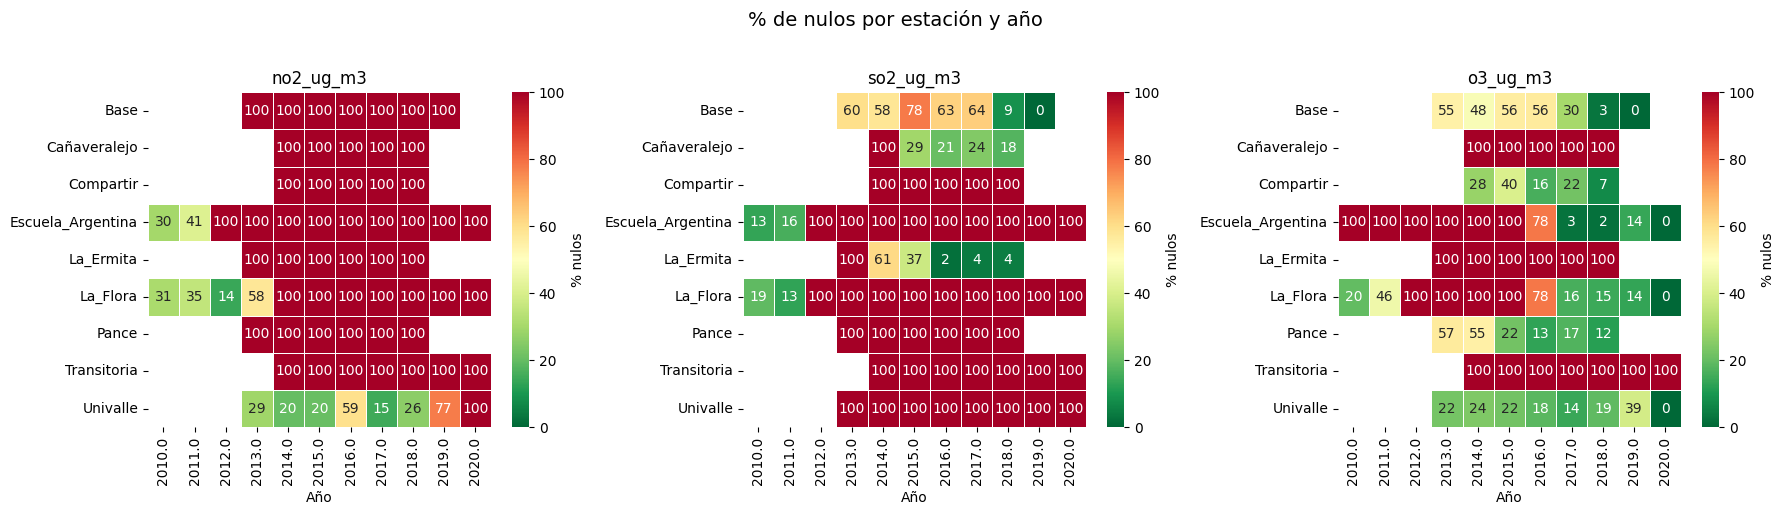

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['no2_ug_m3','so2_ug_m3','o3_ug_m3']):
    pivot = df.groupby(['estacion','año'])[col].apply(
        lambda x: round(x.isna().sum() / len(x) * 100, 1)
    ).unstack()
    
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
                vmin=0, vmax=100, ax=axes[i],
                linewidths=0.5, cbar_kws={'label':'% nulos'})
    axes[i].set_title(col)
    axes[i].set_xlabel('Año')
    axes[i].set_ylabel('')

plt.suptitle('% de nulos por estación y año', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
print(f"Filas antes: {len(df):,}")
df = df.dropna(subset=['fecha_hora'])
print(f"Filas después: {len(df):,}")

Filas antes: 551,988
Filas después: 481,499


In [25]:
# Decisión documentada: no imputar, trabajar con datos reales
# Filtrar solo estaciones que SÍ tienen datos para cada contaminante

estaciones_no2 = ['Escuela_Argentina', 'La_Flora', 'Univalle']
estaciones_so2 = ['Base', 'Cañaveralejo', 'La_Ermita', 'Escuela_Argentina', 'La_Flora']
estaciones_o3  = ['Base', 'Pance', 'Compartir', 'Univalle', 'Escuela_Argentina', 'La_Flora']

print("Estaciones con datos de NO2:", estaciones_no2)
print("Estaciones con datos de SO2:", estaciones_so2)
print("Estaciones con datos de O3: ", estaciones_o3)

# Años con datos suficientes (>20% de cobertura)
print("\nNO2: datos útiles desde 2010 hasta ~2013, luego cae por debajo del 15%")
print("SO2: datos útiles en 2010-2011, luego 2015-2018")
print("O3:  datos útiles desde 2016 en adelante")

Estaciones con datos de NO2: ['Escuela_Argentina', 'La_Flora', 'Univalle']
Estaciones con datos de SO2: ['Base', 'Cañaveralejo', 'La_Ermita', 'Escuela_Argentina', 'La_Flora']
Estaciones con datos de O3:  ['Base', 'Pance', 'Compartir', 'Univalle', 'Escuela_Argentina', 'La_Flora']

NO2: datos útiles desde 2010 hasta ~2013, luego cae por debajo del 15%
SO2: datos útiles en 2010-2011, luego 2015-2018
O3:  datos útiles desde 2016 en adelante


Dado que los nulos son de naturaleza estructural (estaciones sin sensor) y temporal (años sin medición), se decide no imputar. El análisis se realiza sobre los registros válidos disponibles, especificando para cada contaminante las estaciones y períodos con cobertura suficiente.

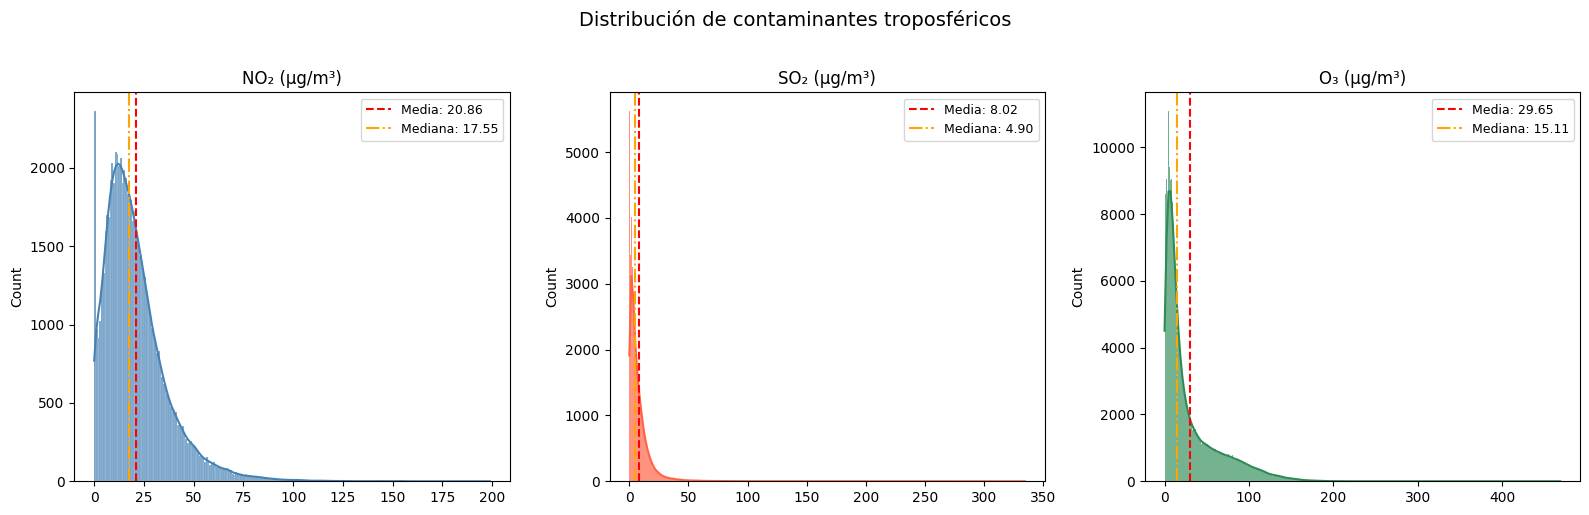

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

contaminantes = {
    'no2_ug_m3': 'NO₂ (µg/m³)',
    'so2_ug_m3': 'SO₂ (µg/m³)',
    'o3_ug_m3':  'O₃ (µg/m³)'
}

for i, (col, label) in enumerate(contaminantes.items()):
    data = df[col].dropna()
    sns.histplot(data, kde=True, ax=axes[i],
                 color=['steelblue','tomato','seagreen'][i],
                 edgecolor='white', alpha=0.75)
    axes[i].axvline(data.mean(),   color='red',    linestyle='--', lw=1.5,
                    label=f'Media: {data.mean():.2f}')
    axes[i].axvline(data.median(), color='orange', linestyle='-.', lw=1.5,
                    label=f'Mediana: {data.median():.2f}')
    axes[i].set_title(label)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribución de contaminantes troposféricos', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figuras/dist_contaminantes.png', bbox_inches='tight', dpi=150)
plt.show()

/tmp/ipykernel_21601/476698395.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='estacion', y=col, ax=axes[i],
/tmp/ipykernel_21601/476698395.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='estacion', y=col, ax=axes[i],


/tmp/ipykernel_21601/476698395.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='estacion', y=col, ax=axes[i],


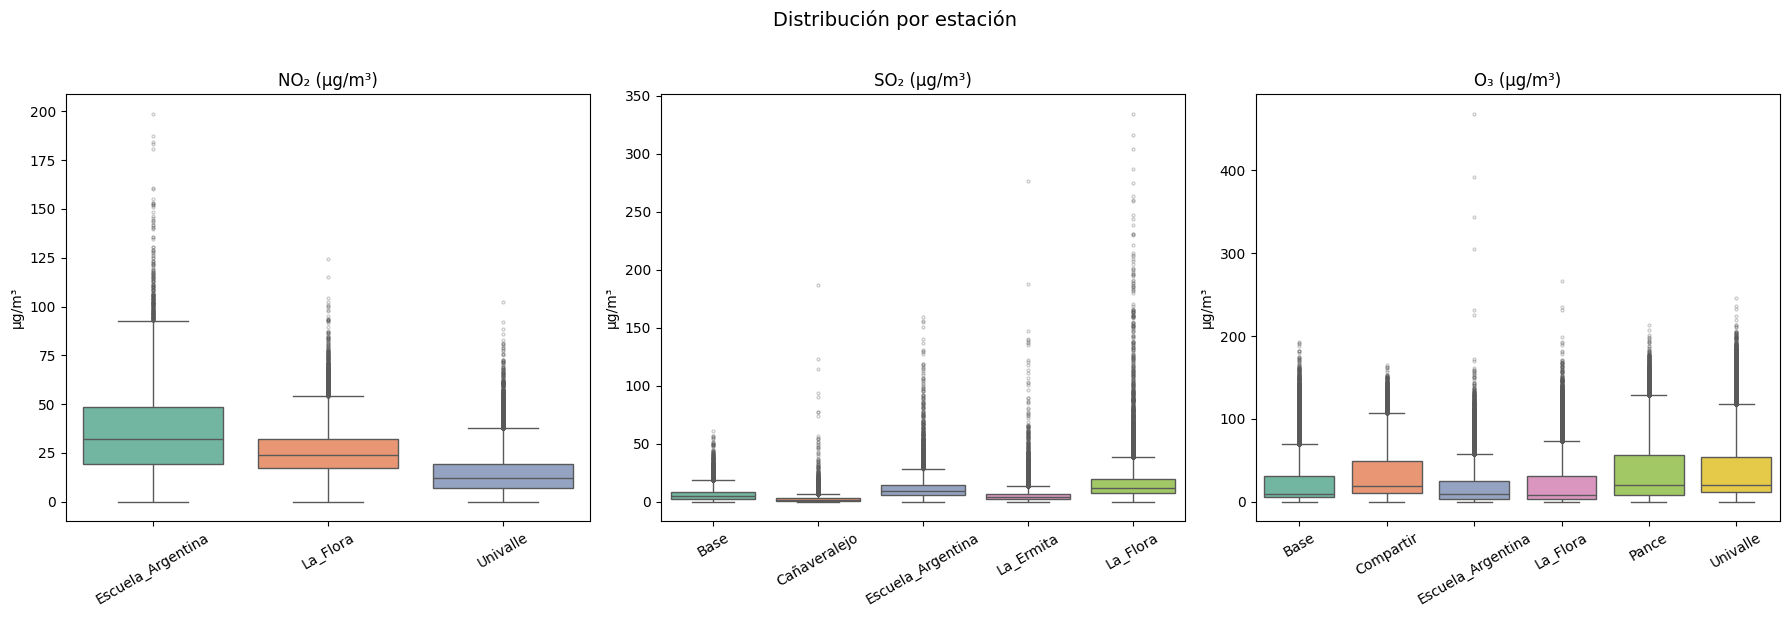

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (col, label) in enumerate(contaminantes.items()):
    data = df[df[col].notna()]
    sns.boxplot(data=data, x='estacion', y=col, ax=axes[i],
                palette='Set2',
                flierprops={'marker':'o','markersize':2,'alpha':0.3})
    axes[i].set_title(label)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('µg/m³')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Distribución por estación', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figuras/boxplot_estaciones.png', bbox_inches='tight', dpi=150)
plt.show()

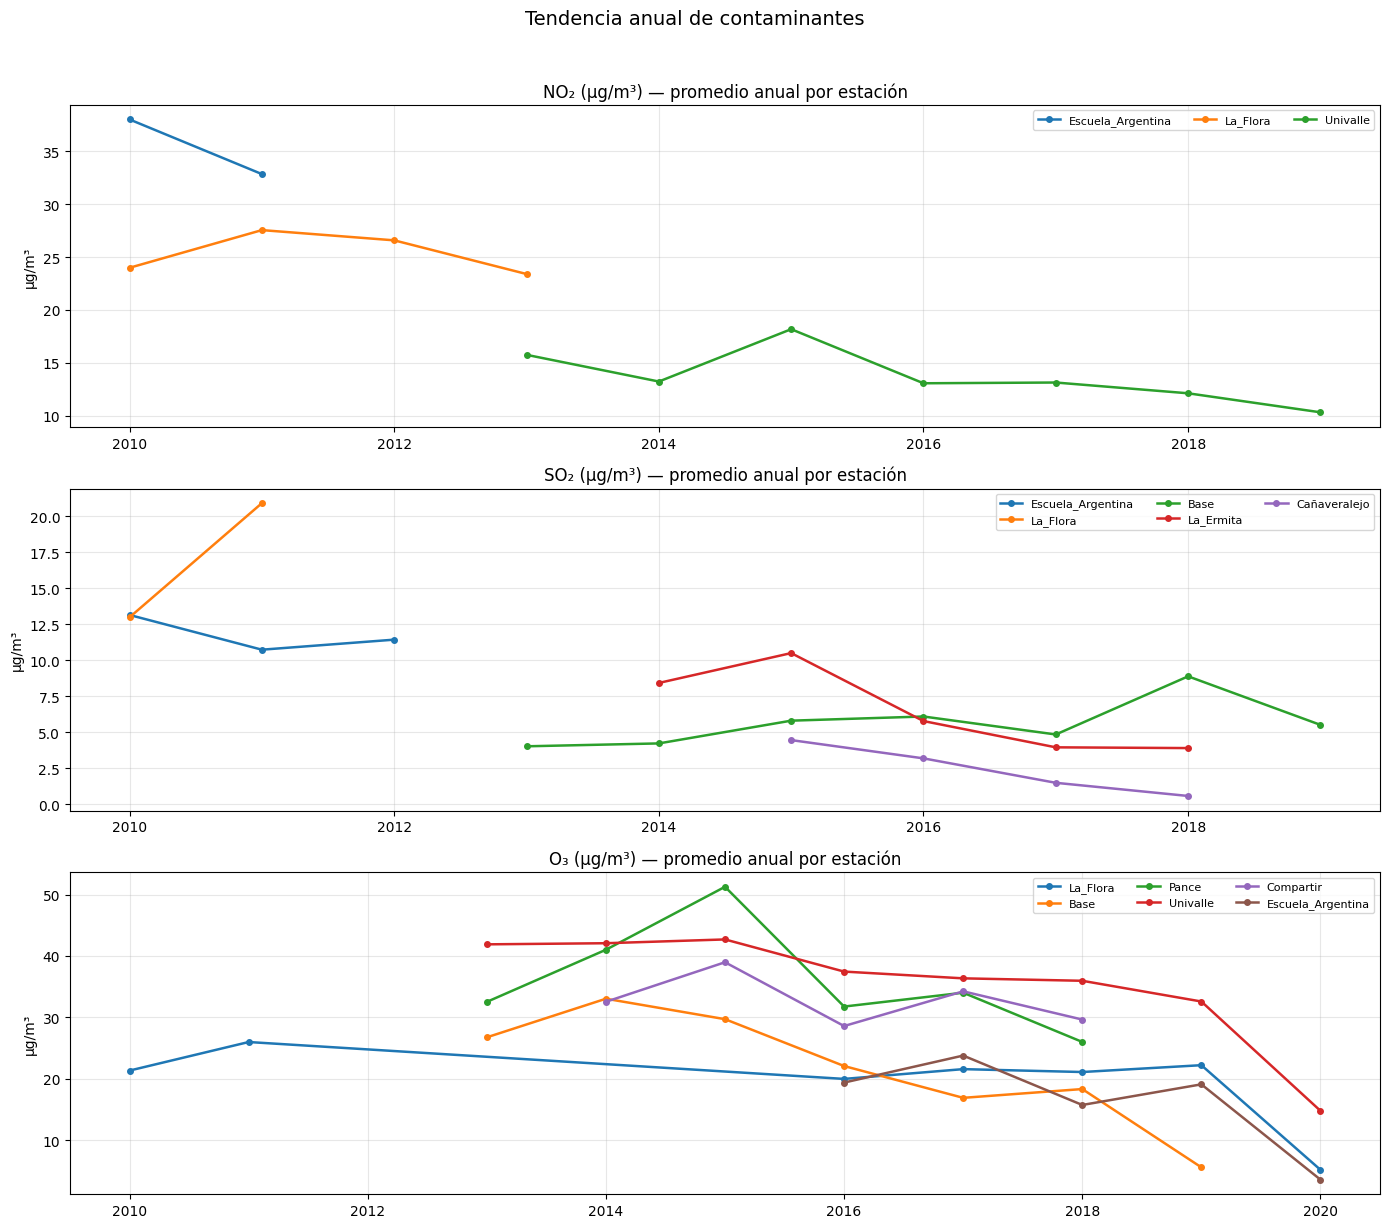

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for i, (col, label) in enumerate(contaminantes.items()):
    anual = (df[df[col].notna()]
             .groupby(['año', 'estacion'])[col]
             .mean()
             .reset_index())

    for estacion in anual['estacion'].unique():
        sub = anual[anual['estacion'] == estacion]
        axes[i].plot(sub['año'], sub[col], marker='o',
                     linewidth=1.8, markersize=4, label=estacion)

    axes[i].set_title(f'{label} — promedio anual por estación')
    axes[i].set_ylabel('µg/m³')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8, ncol=3)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Tendencia anual de contaminantes', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figuras/tendencia_anual.png', bbox_inches='tight', dpi=150)
plt.show()

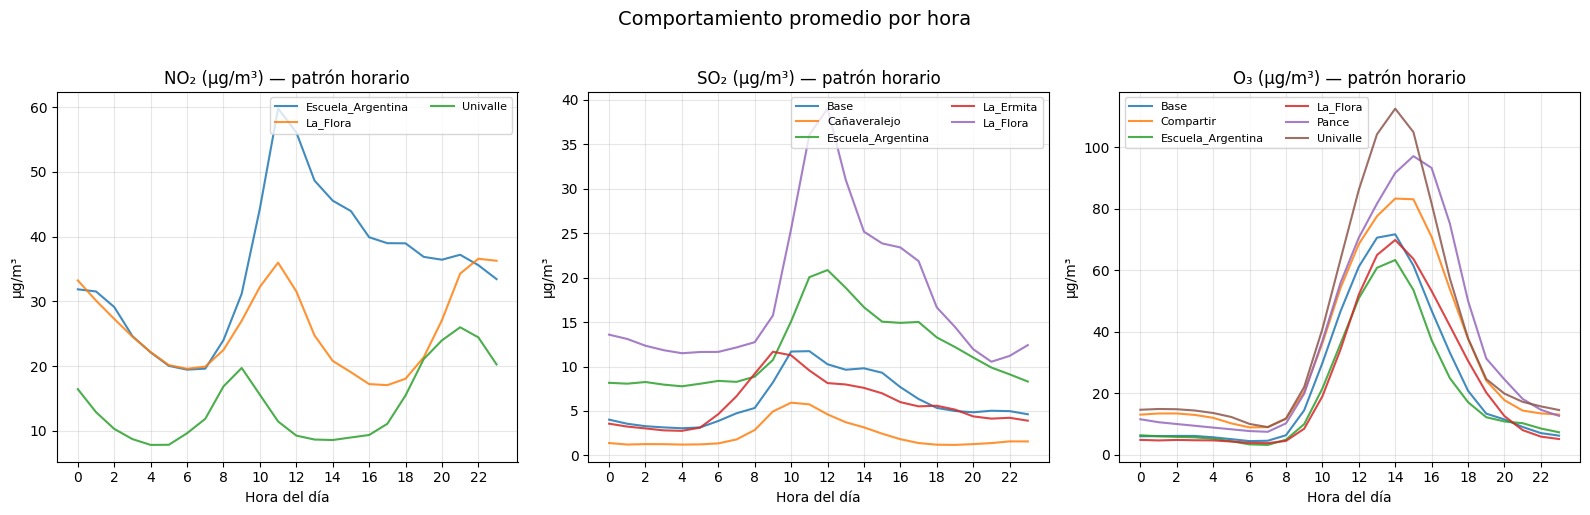

In [29]:
df['hora'] = df['fecha_hora'].dt.hour

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (col, label) in enumerate(contaminantes.items()):
    horario = (df[df[col].notna()]
               .groupby(['hora', 'estacion'])[col]
               .mean()
               .reset_index())

    for estacion in horario['estacion'].unique():
        sub = horario[horario['estacion'] == estacion]
        axes[i].plot(sub['hora'], sub[col],
                     linewidth=1.5, label=estacion, alpha=0.85)

    axes[i].set_title(f'{label} — patrón horario')
    axes[i].set_xlabel('Hora del día')
    axes[i].set_ylabel('µg/m³')
    axes[i].set_xticks(range(0, 24, 2))
    axes[i].legend(fontsize=8, ncol=2)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Comportamiento promedio por hora', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figuras/patron_horario.png', bbox_inches='tight', dpi=150)
plt.show()

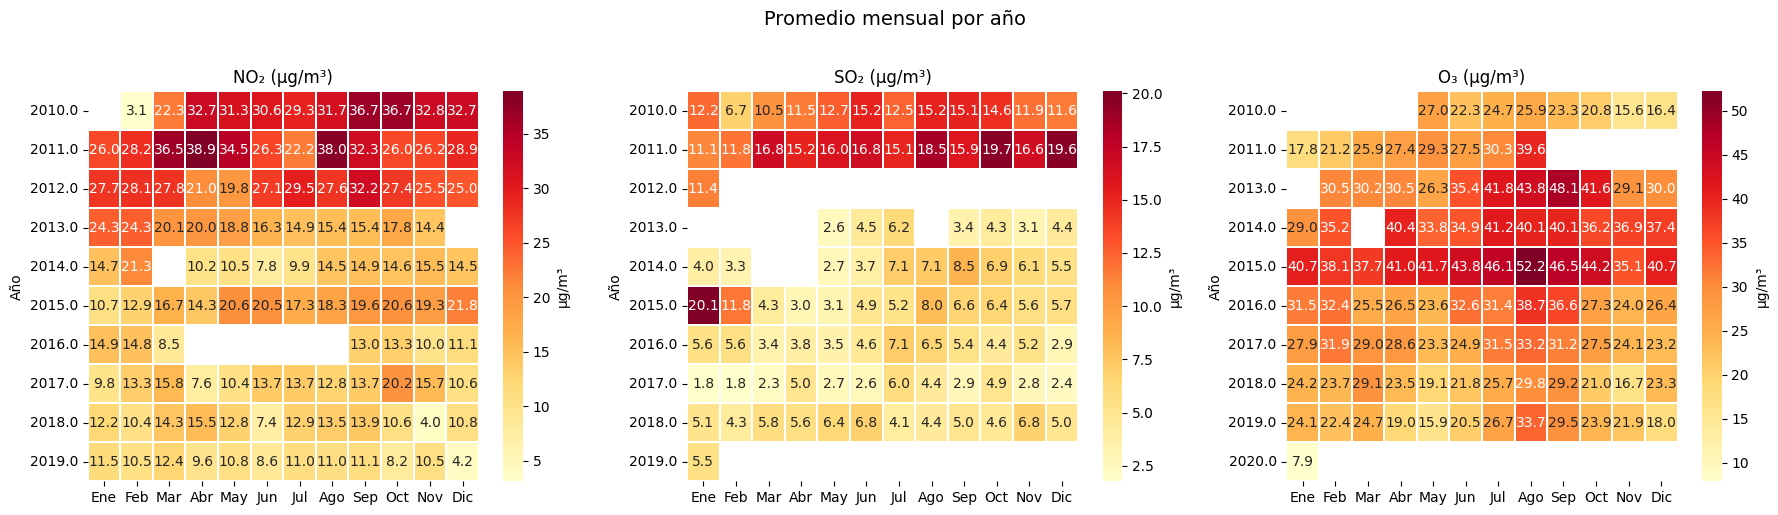

In [30]:
df['mes'] = df['fecha_hora'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

for i, (col, label) in enumerate(contaminantes.items()):
    pivot = (df[df[col].notna()]
             .groupby(['año', 'mes'])[col]
             .mean()
             .unstack())
    pivot.columns = meses[:len(pivot.columns)]

    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
                ax=axes[i], linewidths=0.3,
                cbar_kws={'label': 'µg/m³'})
    axes[i].set_title(label)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Año')

plt.suptitle('Promedio mensual por año', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figuras/heatmap_mensual.png', bbox_inches='tight', dpi=150)
plt.show()

<Axes: xlabel='estacion', ylabel='so2_ug_m3'>

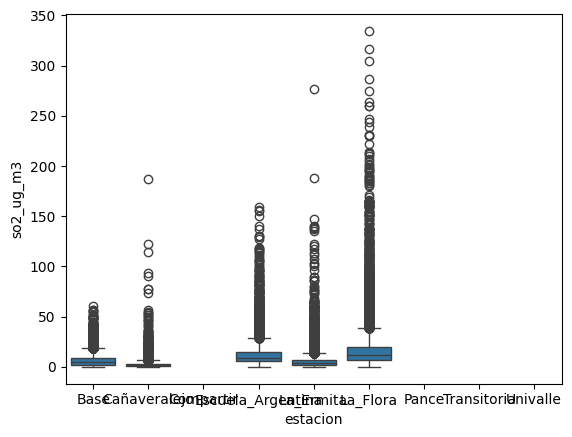

In [31]:
# Cada análisis usa solo sus datos reales — pandas ignora NaN por defecto
df['no2_ug_m3'].mean()    # ignora NaN automáticamente
df.groupby('estacion')['o3_ug_m3'].describe()  # igual
sns.boxplot(data=df, x='estacion', y='so2_ug_m3')  # igual

In [32]:
def detectar_episodios(df, col, estacion, umbral_percentil=90):
    datos = (df[(df['estacion']==estacion) & df[col].notna()]
             .set_index('fecha_hora')[col]
             .resample('D').mean()
             .dropna())
    
    if len(datos) < 30:
        return pd.DataFrame(), None
    
    umbral = datos.quantile(umbral_percentil/100)
    excede = (datos > umbral).astype(int)
    
    episodios = []
    inicio = None
    fecha_anterior = None

    for fecha, val in excede.items():
        if val == 1 and inicio is None:
            inicio = fecha
        elif val == 0 and inicio is not None:
            duracion = (fecha - inicio).days
            segmento = datos[inicio:fecha_anterior]
            if len(segmento) > 0:
                episodios.append({
                    'inicio':         inicio,
                    'fin':            fecha_anterior,
                    'duracion_dias':  max(duracion, 1),
                    'max_valor':      round(float(segmento.max()), 2),
                    'media_episodio': round(float(segmento.mean()), 2),
                    'año':            inicio.year,
                    'mes':            inicio.month,
                    'trimestre':      f"Q{(inicio.month-1)//3+1}"
                })
            inicio = None
        fecha_anterior = fecha

    # cerrar episodio si termina al final de la serie
    if inicio is not None:
        segmento = datos[inicio:]
        duracion = (datos.index[-1] - inicio).days
        episodios.append({
            'inicio':         inicio,
            'fin':            datos.index[-1],
            'duracion_dias':  max(duracion, 1),
            'max_valor':      round(float(segmento.max()), 2),
            'media_episodio': round(float(segmento.mean()), 2),
            'año':            inicio.year,
            'mes':            inicio.month,
            'trimestre':      f"Q{(inicio.month-1)//3+1}"
        })
    
    return pd.DataFrame(episodios), float(umbral)

In [33]:
# ── Resumen global ──
print(f"\n{'═'*65}")
print("  RESUMEN GLOBAL — TODOS LOS CONTAMINANTES Y ESTACIONES")
print(f"{'═'*65}")

if resumen_global:
    df_resumen = pd.DataFrame(resumen_global)
    display(df_resumen.sort_values(
        ['contaminante','concentracion_max'],
        ascending=[True, False]
    ))
    criticos = df_resumen[df_resumen['supera_norma'] == True]
    if not criticos.empty:
        print(f"\n⚠  ESTACIONES QUE SUPERAN LÍMITE NORMATIVO:")
        display(criticos[['contaminante','estacion',
                           'concentracion_max','limite_norma','año_peak']])
    else:
        print("\n✓ Ninguna estación supera el límite normativo")
else:
    print("\n  No se detectaron episodios en ninguna estación.")
    print("  Posibles causas:")
    print("  · La serie diaria tiene muy pocos días continuos sobre el p90")
    print("  · Revisa que df tenga la columna 'fecha_hora' como datetime")
    print(f"  · dtype fecha_hora: {df['fecha_hora'].dtype}")
    print(f"  · Ejemplo valores: {df['fecha_hora'].dropna().head(3).tolist()}")


═════════════════════════════════════════════════════════════════
  RESUMEN GLOBAL — TODOS LOS CONTAMINANTES Y ESTACIONES
═════════════════════════════════════════════════════════════════

  No se detectaron episodios en ninguna estación.
  Posibles causas:
  · La serie diaria tiene muy pocos días continuos sobre el p90
  · Revisa que df tenga la columna 'fecha_hora' como datetime
  · dtype fecha_hora: datetime64[ns]
  · Ejemplo valores: [Timestamp('2013-03-09 00:00:00'), Timestamp('2013-03-09 01:00:00'), Timestamp('2013-03-09 02:00:00')]


In [34]:
# ══════════════════════════════════════════════════════════════════
# ANÁLISIS PROFUNDO DE CONTAMINANTES — NO₂, SO₂, O₃
# DAGMA Cali 2010–2020
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, normaltest
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, ccf
import warnings
warnings.filterwarnings('ignore')

contaminantes = {
    'no2_ug_m3': ('NO₂', 'steelblue'),
    'so2_ug_m3': ('SO₂', 'tomato'),
    'o3_ug_m3':  ('O₃',  'seagreen'),
}

limites_norma = {
    'no2_ug_m3': {'anual': 40,  'diario': 200},
    'so2_ug_m3': {'anual': 50,  'diario': 125},
    'o3_ug_m3':  {'anual': 100, 'diario': 120},
}

ESTADÍSTICA DESCRIPTIVA PROFUNDA POR CONTAMINANTE Y ESTACIÓN

══════════════════════════════════════════════════════════════════════
  NO₂ — 3 estaciones con datos
══════════════════════════════════════════════════════════════════════


,n,media,mediana,std,cv_%,p5,p25,p75,p95,p99,max,skew,kurt,iqr
estacion,,,,,,,,,,,,,,
Escuela_Argentina,10851,35.558,31.99,23.258,65.409,2.775,19.245,48.645,78.55,105.030,198.84,1.044,2.132,29.40
La_Flora,20853,25.783,23.65,12.328,47.812,9.740,17.220,32.040,48.98,65.304,124.50,1.197,2.580,14.82
Univalle,38676,14.087,12.10,10.299,73.108,0.700,6.820,19.100,33.79,47.332,102.12,1.315,2.842,12.28


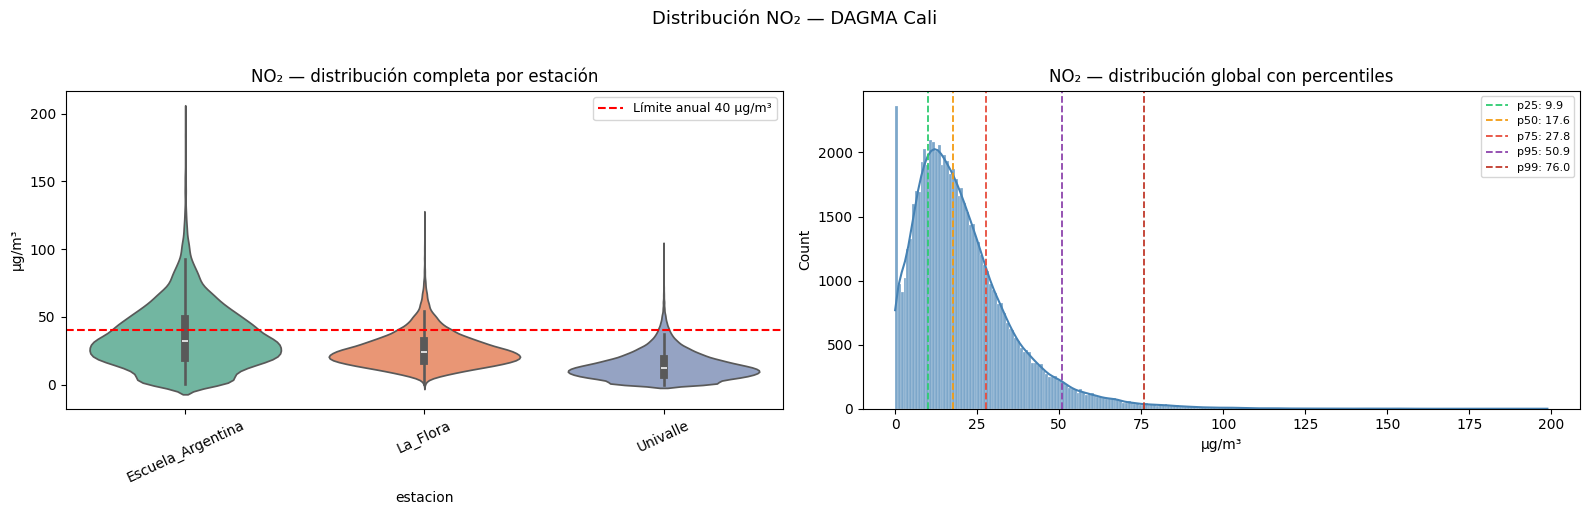


══════════════════════════════════════════════════════════════════════
  SO₂ — 5 estaciones con datos
══════════════════════════════════════════════════════════════════════


,n,media,mediana,std,cv_%,p5,p25,p75,p95,p99,max,skew,kurt,iqr
estacion,,,,,,,,,,,,,,
Base,22972,6.296,4.93,5.672,90.079,0.52,2.12,8.650,17.000,26.460,60.66,2.044,7.475,6.530
Cañaveralejo,16344,2.352,1.28,4.249,180.637,0.00,0.30,2.730,8.620,16.077,186.69,12.353,345.086,2.430
Escuela_Argentina,14370,11.901,9.19,11.055,92.893,2.11,5.55,14.730,29.941,55.068,159.14,4.023,28.928,9.180
La_Ermita,20779,5.877,3.54,7.706,131.116,1.00,2.20,6.730,17.601,33.960,276.70,7.936,143.511,4.530
La_Flora,12234,17.904,11.64,22.098,123.421,3.37,7.24,19.655,51.971,117.293,334.60,4.951,36.824,12.415


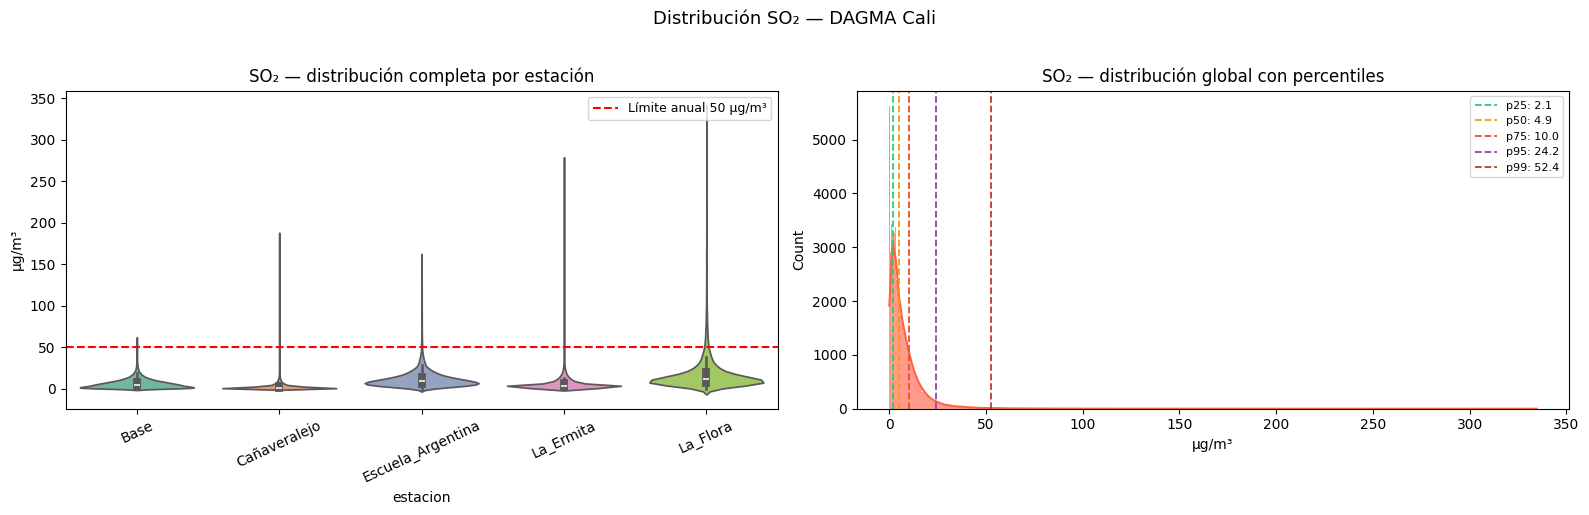


══════════════════════════════════════════════════════════════════════
  O₃ — 6 estaciones con datos
══════════════════════════════════════════════════════════════════════


,n,media,mediana,std,cv_%,p5,p25,p75,p95,p99,max,skew,kurt,iqr
estacion,,,,,,,,,,,,,,
Base,30088,23.112,9.64,28.772,124.490,1.337,5.10,30.890,88.779,126.718,193.10,1.986,3.869,25.790
Compartir,33195,32.331,18.64,29.737,91.979,5.000,10.50,49.240,94.100,119.160,165.51,1.274,0.791,38.740
Escuela_Argentina,26514,19.548,9.34,24.321,124.416,0.900,3.69,25.200,73.107,103.187,468.50,2.358,11.842,21.510
La_Flora,33641,22.123,8.10,28.466,128.672,0.600,3.53,31.200,85.760,116.660,266.30,1.810,3.138,27.670
Pance,36338,35.752,19.83,37.001,103.494,1.980,7.40,55.745,113.233,146.343,212.72,1.280,0.864,48.345
Univalle,46294,38.464,20.55,39.434,102.522,4.600,11.03,53.910,125.240,159.346,246.12,1.473,1.366,42.880


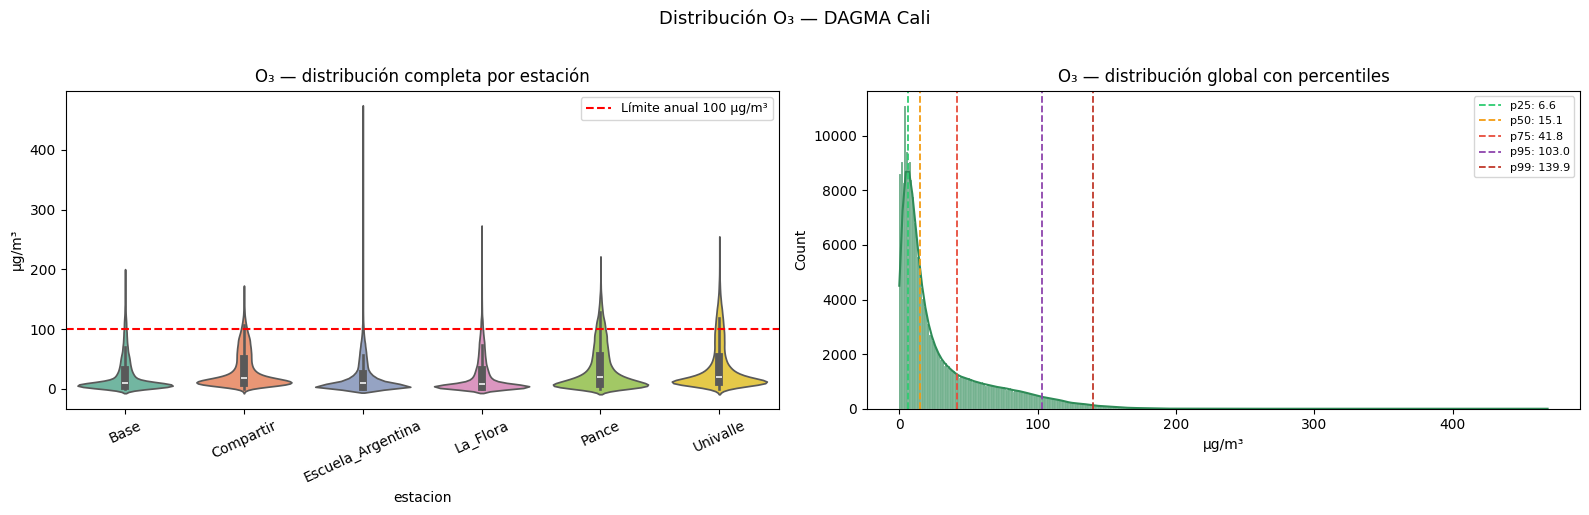

In [35]:
# ══════════════════════════════════════════════════════════════════
# BLOQUE 1 — ESTADÍSTICA DESCRIPTIVA PROFUNDA
# ══════════════════════════════════════════════════════════════════

print("ESTADÍSTICA DESCRIPTIVA PROFUNDA POR CONTAMINANTE Y ESTACIÓN")

for col, (nombre, color) in contaminantes.items():
    estaciones = sorted(df[df[col].notna()]['estacion'].unique())
    if not estaciones:
        continue

    print(f"\n{'═'*70}")
    print(f"  {nombre} — {len(estaciones)} estaciones con datos")
    print(f"{'═'*70}")

    rows = []
    for est in estaciones:
        s = df[(df['estacion']==est) & df[col].notna()][col]
        rows.append({
            'estacion':   est,
            'n':          len(s),
            'media':      s.mean(),
            'mediana':    s.median(),
            'std':        s.std(),
            'cv_%':       s.std()/s.mean()*100 if s.mean()!=0 else np.nan,
            'p5':         s.quantile(0.05),
            'p25':        s.quantile(0.25),
            'p75':        s.quantile(0.75),
            'p95':        s.quantile(0.95),
            'p99':        s.quantile(0.99),
            'max':        s.max(),
            'skew':       s.skew(),
            'kurt':       s.kurtosis(),
            'iqr':        s.quantile(0.75) - s.quantile(0.25),
        })

    tbl = pd.DataFrame(rows).set_index('estacion').round(3)
    display(tbl)

    # Violin plot por estación — muestra distribución completa
    data_plot = df[df[col].notna()][['estacion', col]]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.violinplot(data=data_plot, x='estacion', y=col,
                   palette='Set2', inner='box', ax=axes[0])
    axes[0].axhline(limites_norma[col]['anual'], color='red',
                    linestyle='--', lw=1.5,
                    label=f'Límite anual {limites_norma[col]["anual"]} µg/m³')
    axes[0].set_title(f'{nombre} — distribución completa por estación')
    axes[0].tick_params(axis='x', rotation=25)
    axes[0].set_ylabel('µg/m³')
    axes[0].legend(fontsize=9)

    # Distribución global + percentiles marcados
    s_global = df[df[col].notna()][col]
    sns.histplot(s_global, kde=True, ax=axes[1],
                 color=color, edgecolor='white', alpha=0.7)
    for p, lbl, c in [(0.25,'p25','#2ecc71'),
                      (0.50,'p50','#f39c12'),
                      (0.75,'p75','#e74c3c'),
                      (0.95,'p95','#8e44ad'),
                      (0.99,'p99','#c0392b')]:
        v = s_global.quantile(p)
        axes[1].axvline(v, linestyle='--', lw=1.3, color=c,
                        label=f'{lbl}: {v:.1f}')
    axes[1].set_title(f'{nombre} — distribución global con percentiles')
    axes[1].set_xlabel('µg/m³')
    axes[1].legend(fontsize=8)

    plt.suptitle(f'Distribución {nombre} — DAGMA Cali', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(f'figuras/dist_profunda_{col}.png', bbox_inches='tight', dpi=150)
    plt.show()

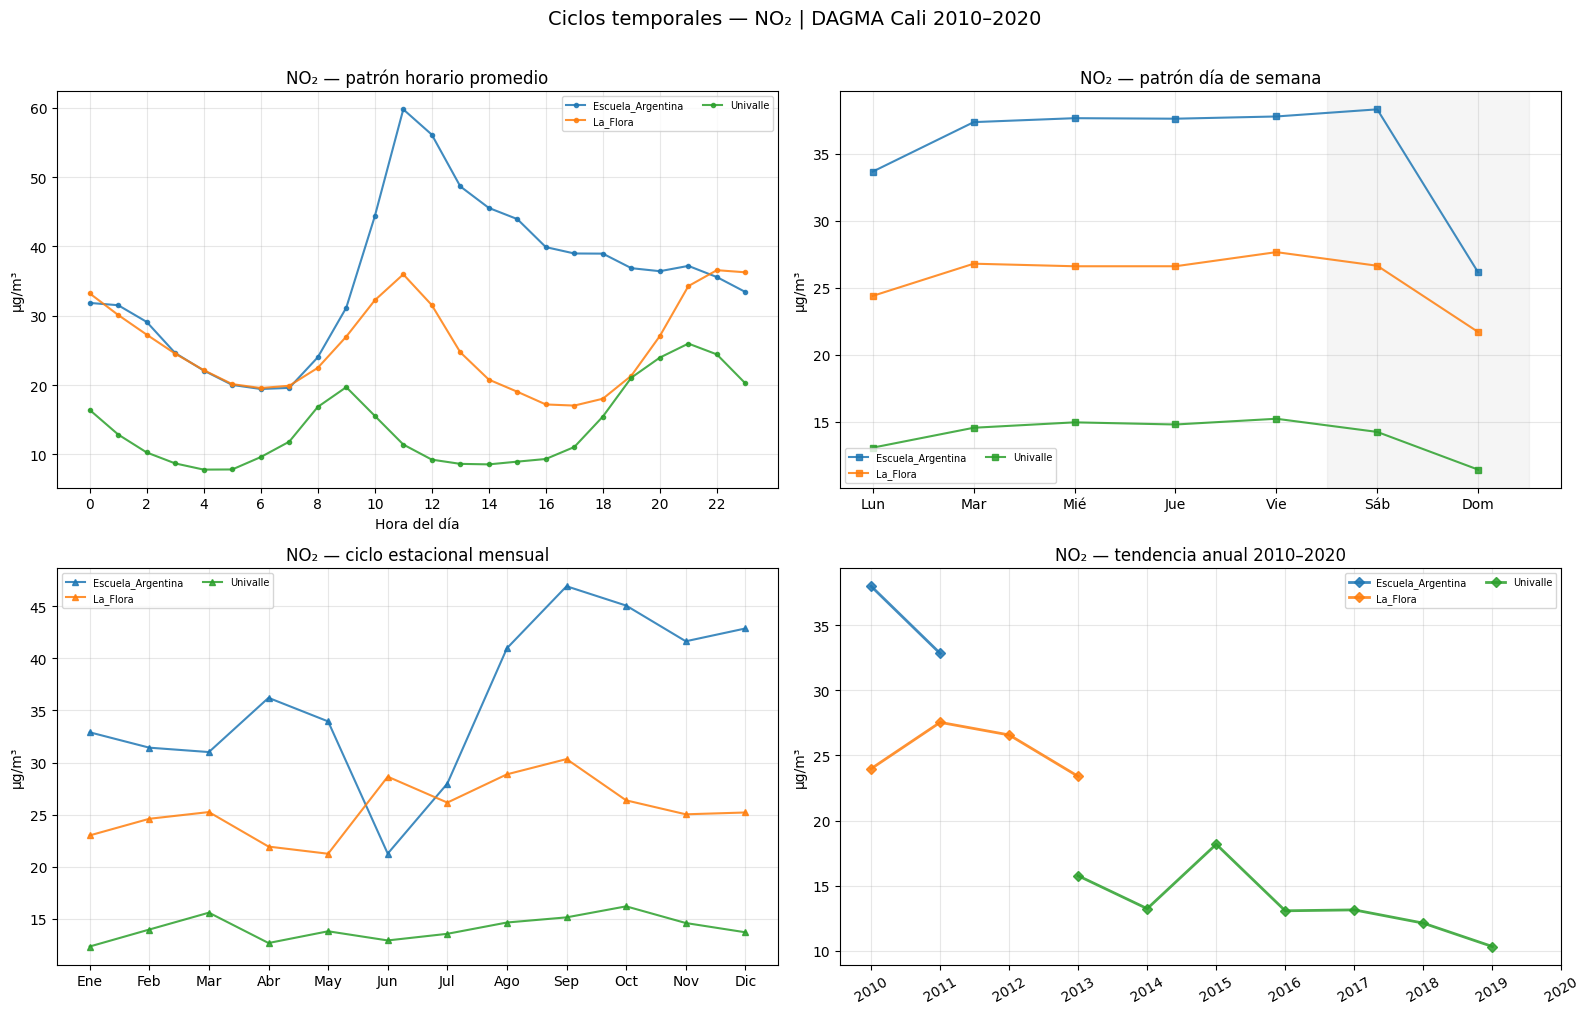

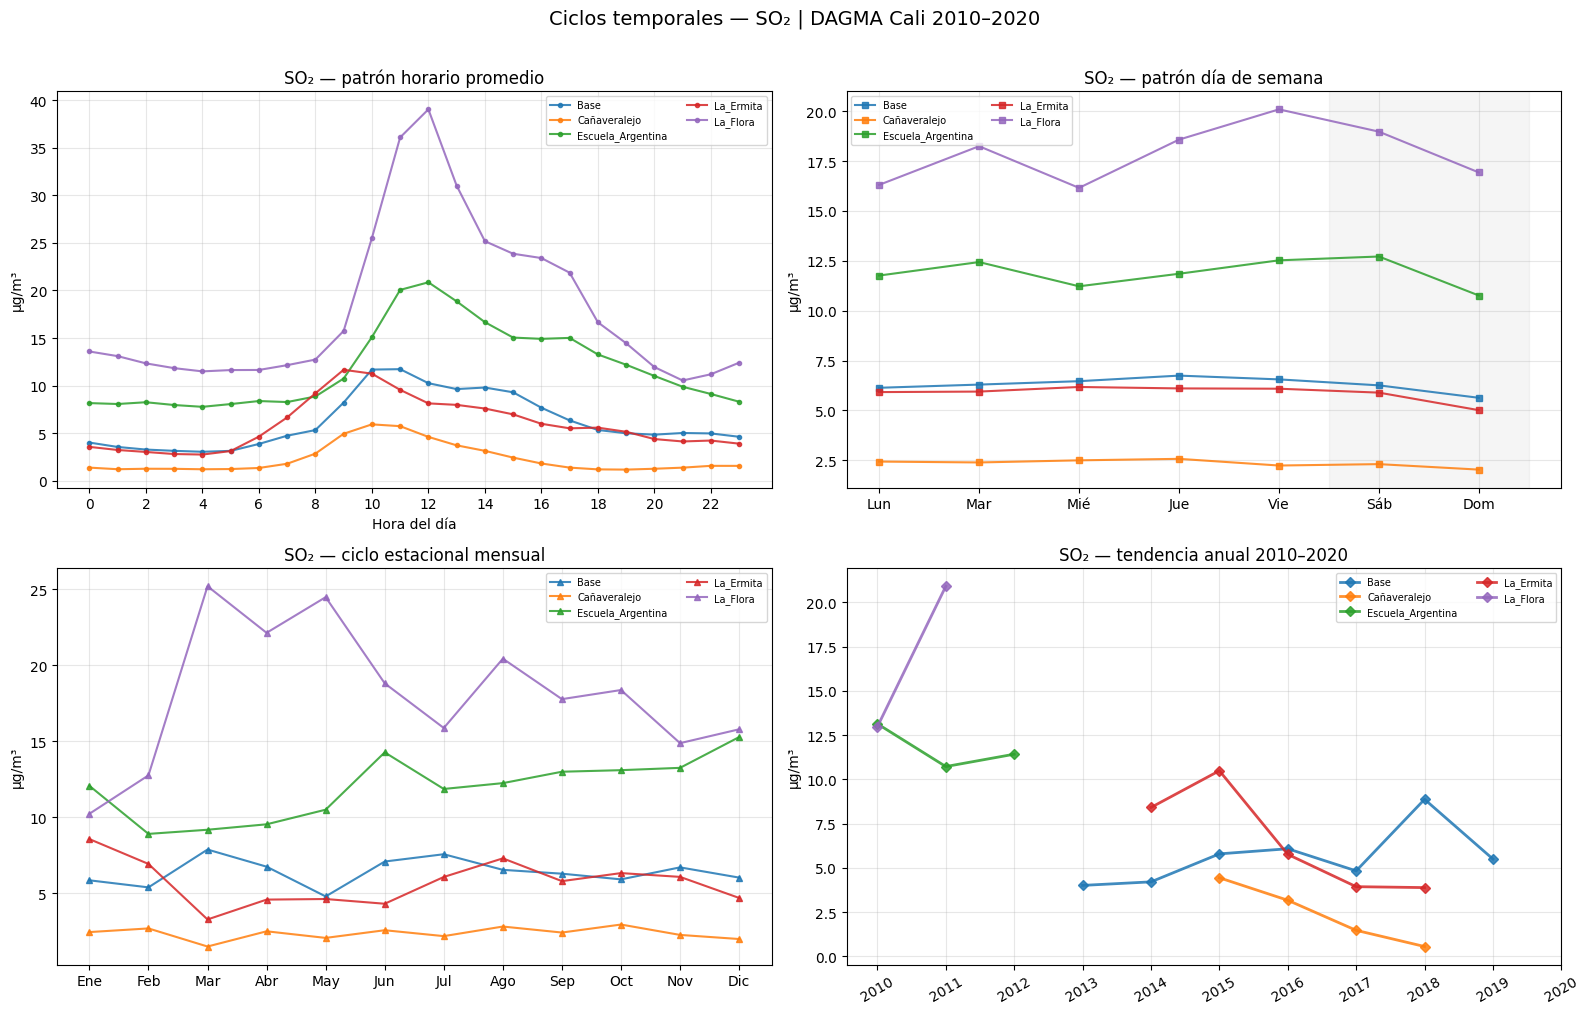

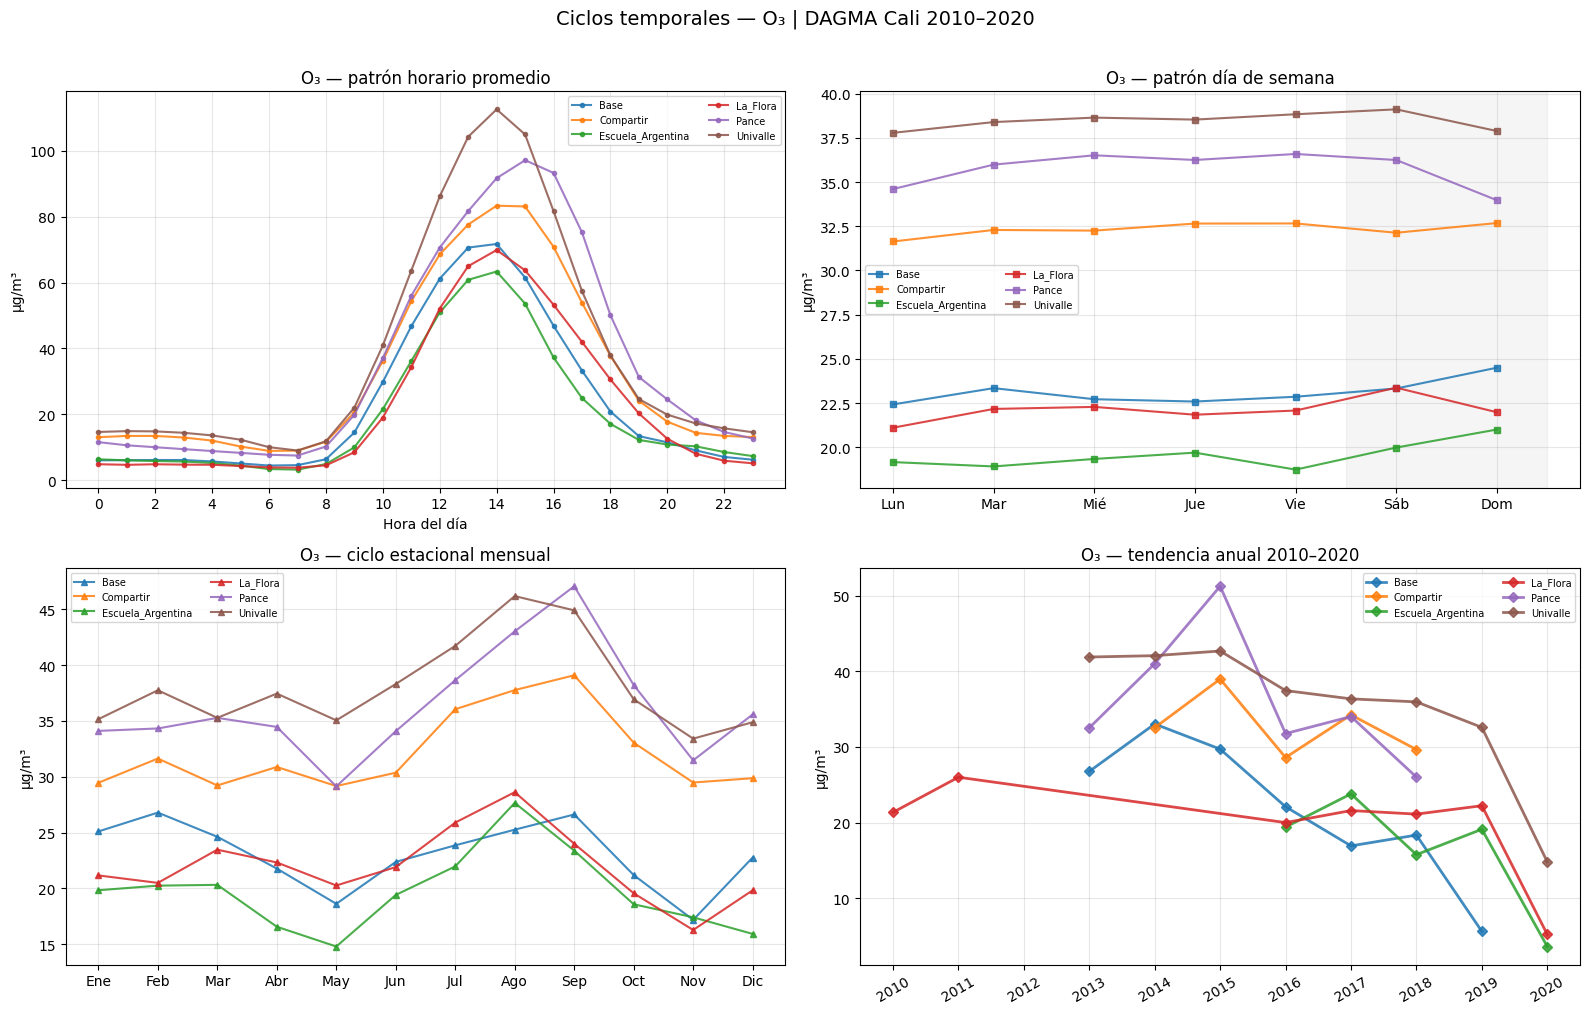

In [36]:
# ══════════════════════════════════════════════════════════════════
# BLOQUE 2 — CICLOS TEMPORALES: HORA, DÍA, MES, AÑO
# ══════════════════════════════════════════════════════════════════

df['hora']      = df['fecha_hora'].dt.hour
df['dia_semana']= df['fecha_hora'].dt.dayofweek   # 0=lunes
df['mes']       = df['fecha_hora'].dt.month
df['año']       = df['fecha_hora'].dt.year
df['dia_nombre']= df['fecha_hora'].dt.day_name()
df['mes_nombre']= df['fecha_hora'].dt.strftime('%b')
nombre_dias     = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
nombre_meses    = ['Ene','Feb','Mar','Abr','May','Jun',
                   'Jul','Ago','Sep','Oct','Nov','Dic']

for col, (nombre, color) in contaminantes.items():
    estaciones = sorted(df[df[col].notna()]['estacion'].unique())
    if not estaciones:
        continue

    datos = df[df[col].notna()]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # ── Patrón horario por estación ──
    for est in estaciones:
        h = (datos[datos['estacion']==est]
             .groupby('hora')[col].mean())
        axes[0,0].plot(h.index, h.values, marker='o',
                       markersize=3, lw=1.5, label=est, alpha=0.85)
    axes[0,0].set_title(f'{nombre} — patrón horario promedio')
    axes[0,0].set_xlabel('Hora del día')
    axes[0,0].set_ylabel('µg/m³')
    axes[0,0].set_xticks(range(0,24,2))
    axes[0,0].legend(fontsize=7, ncol=2)
    axes[0,0].grid(True, alpha=0.3)

    # ── Patrón día de semana ──
    for est in estaciones:
        d = (datos[datos['estacion']==est]
             .groupby('dia_semana')[col].mean())
        axes[0,1].plot(d.index, d.values, marker='s',
                       markersize=4, lw=1.5, label=est, alpha=0.85)
    axes[0,1].set_xticks(range(7))
    axes[0,1].set_xticklabels(nombre_dias)
    axes[0,1].set_title(f'{nombre} — patrón día de semana')
    axes[0,1].set_ylabel('µg/m³')
    axes[0,1].legend(fontsize=7, ncol=2)
    axes[0,1].grid(True, alpha=0.3)

    # Línea vertical fin semana
    axes[0,1].axvspan(4.5, 6.5, alpha=0.08, color='gray', label='Fin de semana')

    # ── Patrón mensual (estacionalidad) ──
    for est in estaciones:
        m = (datos[datos['estacion']==est]
             .groupby('mes')[col].mean())
        axes[1,0].plot(m.index, m.values, marker='^',
                       markersize=4, lw=1.5, label=est, alpha=0.85)
    axes[1,0].set_xticks(range(1,13))
    axes[1,0].set_xticklabels(nombre_meses)
    axes[1,0].set_title(f'{nombre} — ciclo estacional mensual')
    axes[1,0].set_ylabel('µg/m³')
    axes[1,0].legend(fontsize=7, ncol=2)
    axes[1,0].grid(True, alpha=0.3)

    # ── Tendencia anual ──
    for est in estaciones:
        a = (datos[datos['estacion']==est]
             .groupby('año')[col].mean())
        axes[1,1].plot(a.index, a.values, marker='D',
                       markersize=5, lw=2, label=est, alpha=0.85)
    axes[1,1].set_title(f'{nombre} — tendencia anual 2010–2020')
    axes[1,1].set_ylabel('µg/m³')
    axes[1,1].set_xticks(range(2010, 2021))
    axes[1,1].tick_params(axis='x', rotation=30)
    axes[1,1].legend(fontsize=7, ncol=2)
    axes[1,1].grid(True, alpha=0.3)

    plt.suptitle(f'Ciclos temporales — {nombre} | DAGMA Cali 2010–2020',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f'figuras/ciclos_{col}.png', bbox_inches='tight', dpi=150)
    plt.show()

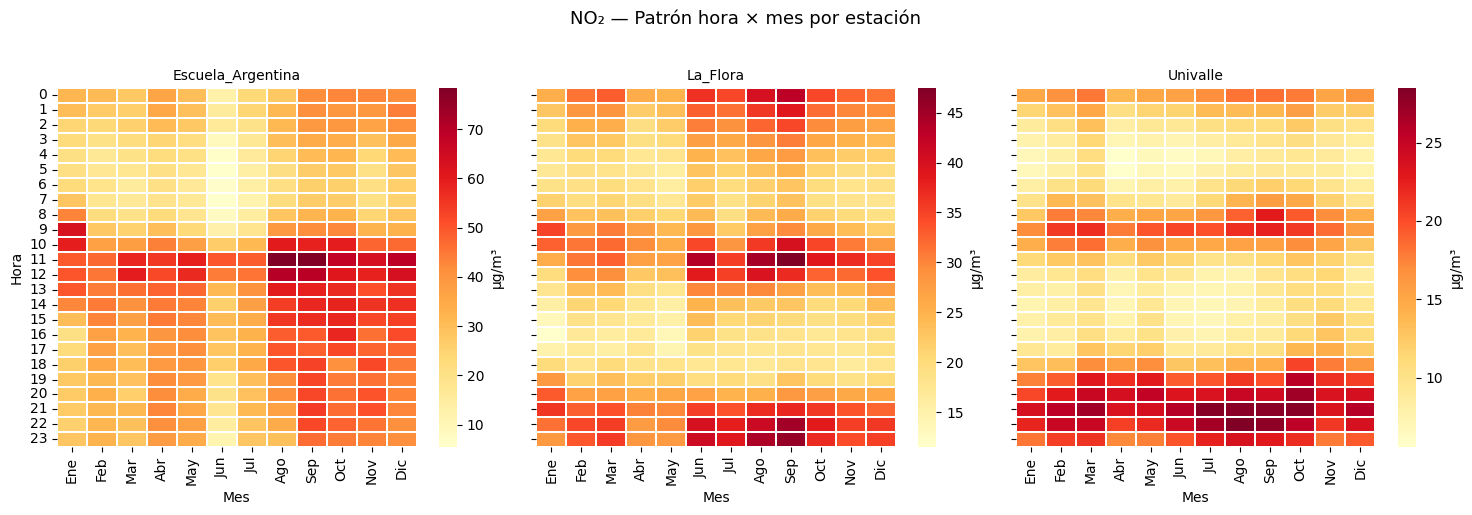

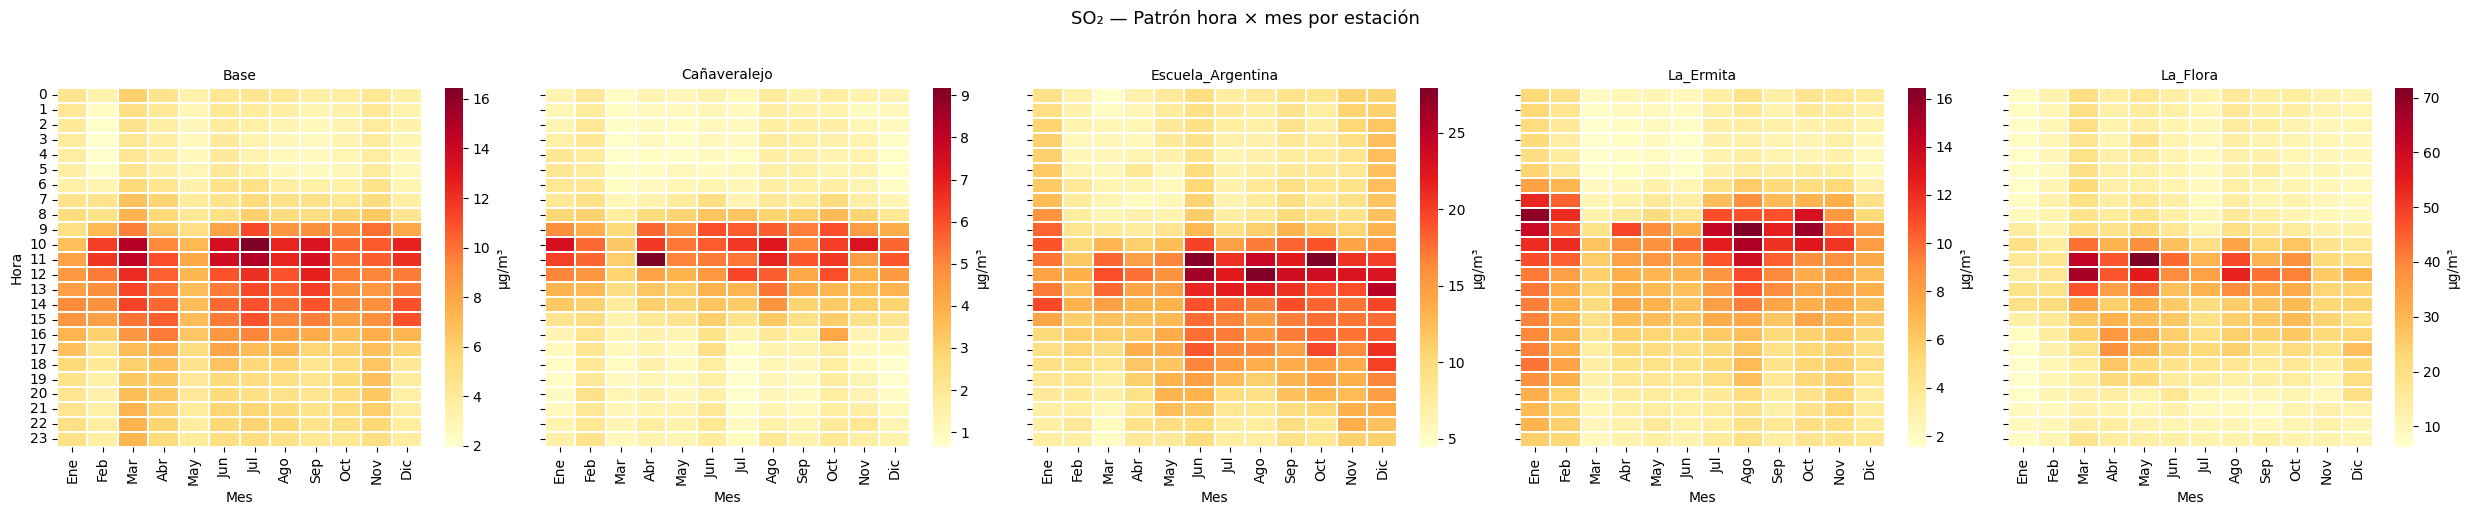

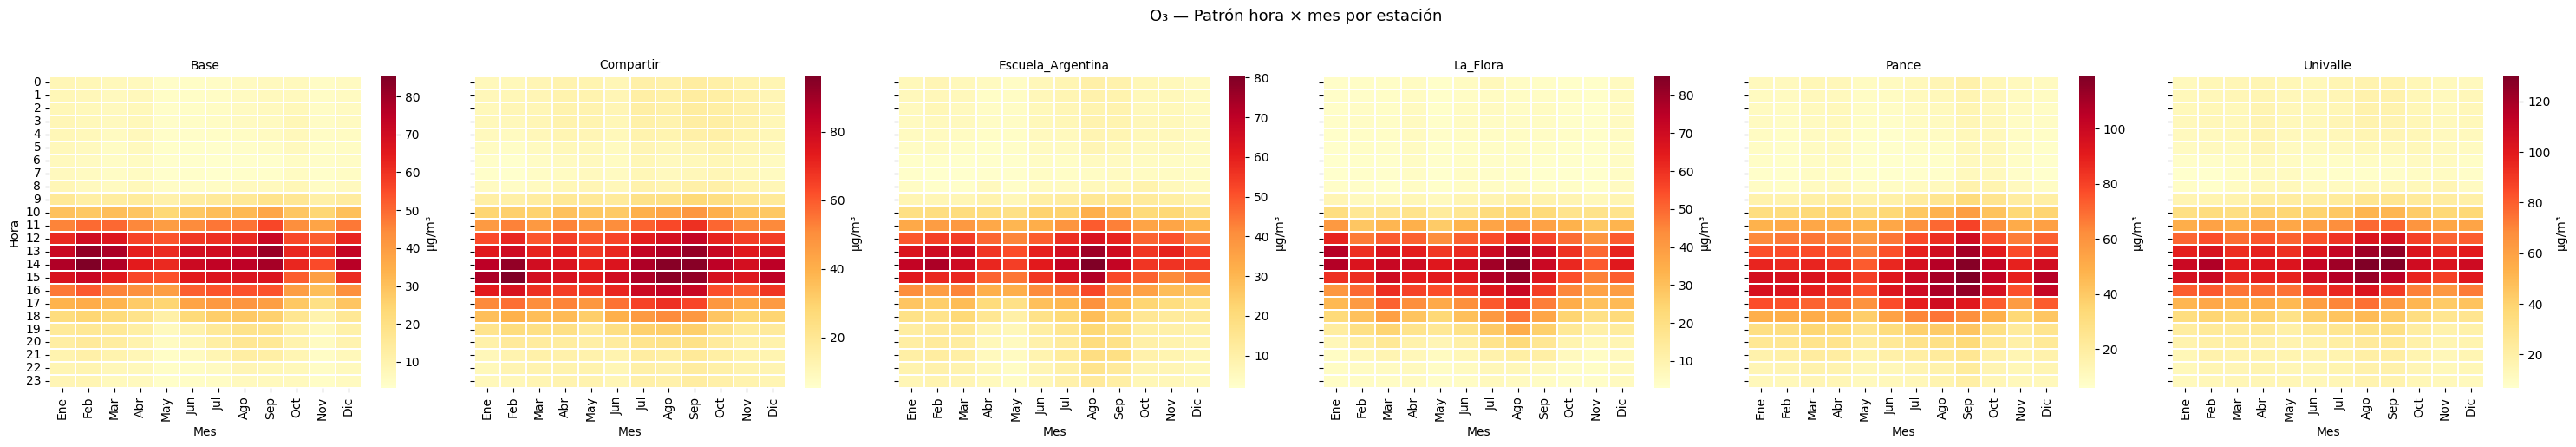

In [37]:
# ══════════════════════════════════════════════════════════════════
# BLOQUE 3 — HEATMAP HORA × MES (patrón intradiario + estacional)
# ══════════════════════════════════════════════════════════════════

for col, (nombre, color) in contaminantes.items():
    estaciones = sorted(df[df[col].notna()]['estacion'].unique())
    if not estaciones:
        continue

    n = len(estaciones)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5), sharey=True)
    if n == 1:
        axes = [axes]

    for i, est in enumerate(estaciones):
        pivot = (df[(df['estacion']==est) & df[col].notna()]
                 .groupby(['hora','mes'])[col].mean()
                 .unstack())
        pivot.columns = [nombre_meses[m-1] for m in pivot.columns]

        sns.heatmap(pivot, cmap='YlOrRd', ax=axes[i],
                    linewidths=0.2, annot=False,
                    cbar_kws={'label':'µg/m³'})
        axes[i].set_title(est, fontsize=10)
        axes[i].set_xlabel('Mes')
        axes[i].set_ylabel('Hora' if i==0 else '')

    plt.suptitle(f'{nombre} — Patrón hora × mes por estación',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(f'figuras/heatmap_hora_mes_{col}.png', bbox_inches='tight', dpi=150)
    plt.show()

TEST ESTADÍSTICO: ¿Difieren los niveles entre días laborales y fin de semana?
(Mann-Whitney U — no paramétrico, robusto a no normalidad)


────────────────────────────────────────────────────────────
  NO₂
────────────────────────────────────────────────────────────
  Escuela_Argentina      | Lab: 36.82  FdS: 32.35  Δ=+13.8%  p=0.0000  → ✓ SÍ difieren
  La_Flora               | Lab: 26.41  FdS: 24.19  Δ=+9.2%  p=0.0000  → ✓ SÍ difieren
  Univalle               | Lab: 14.55  FdS: 12.90  Δ=+12.8%  p=0.0000  → ✓ SÍ difieren


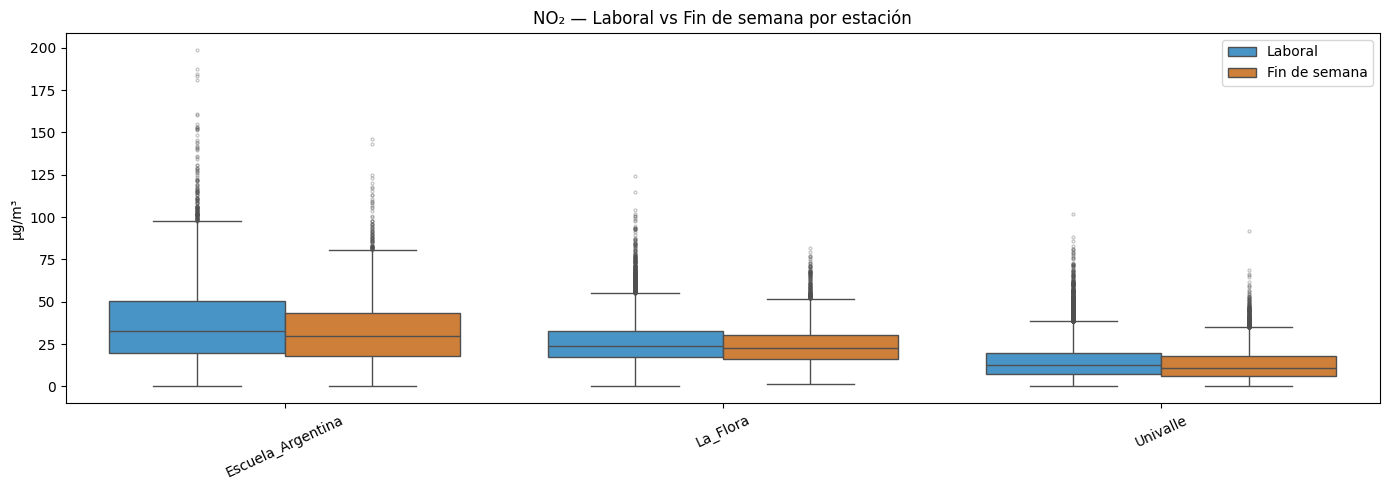


────────────────────────────────────────────────────────────
  SO₂
────────────────────────────────────────────────────────────
  Base                   | Lab: 6.44  FdS: 5.95  Δ=+8.3%  p=0.0000  → ✓ SÍ difieren
  Cañaveralejo           | Lab: 2.43  FdS: 2.17  Δ=+11.8%  p=0.0003  → ✓ SÍ difieren
  Escuela_Argentina      | Lab: 11.96  FdS: 11.76  Δ=+1.7%  p=0.0143  → ✓ SÍ difieren
  La_Ermita              | Lab: 6.05  FdS: 5.46  Δ=+10.8%  p=0.0000  → ✓ SÍ difieren
  La_Flora               | Lab: 17.88  FdS: 17.97  Δ=-0.5%  p=0.1513  → ✗ NO difieren


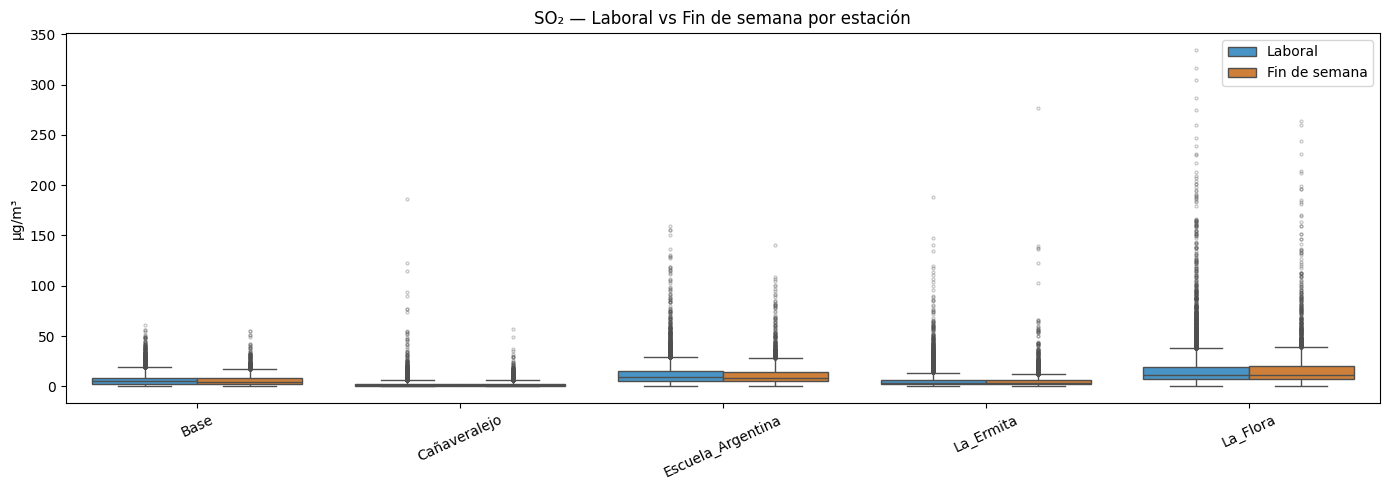


────────────────────────────────────────────────────────────
  O₃
────────────────────────────────────────────────────────────
  Base                   | Lab: 22.78  FdS: 23.91  Δ=-4.7%  p=0.1190  → ✗ NO difieren
  Compartir              | Lab: 32.30  FdS: 32.40  Δ=-0.3%  p=0.0518  → ✗ NO difieren
  Escuela_Argentina      | Lab: 19.17  FdS: 20.49  Δ=-6.5%  p=0.0000  → ✓ SÍ difieren
  La_Flora               | Lab: 21.90  FdS: 22.68  Δ=-3.4%  p=0.0129  → ✓ SÍ difieren
  Pance                  | Lab: 36.00  FdS: 35.11  Δ=+2.5%  p=0.3665  → ✗ NO difieren
  Univalle               | Lab: 38.44  FdS: 38.52  Δ=-0.2%  p=0.5984  → ✗ NO difieren


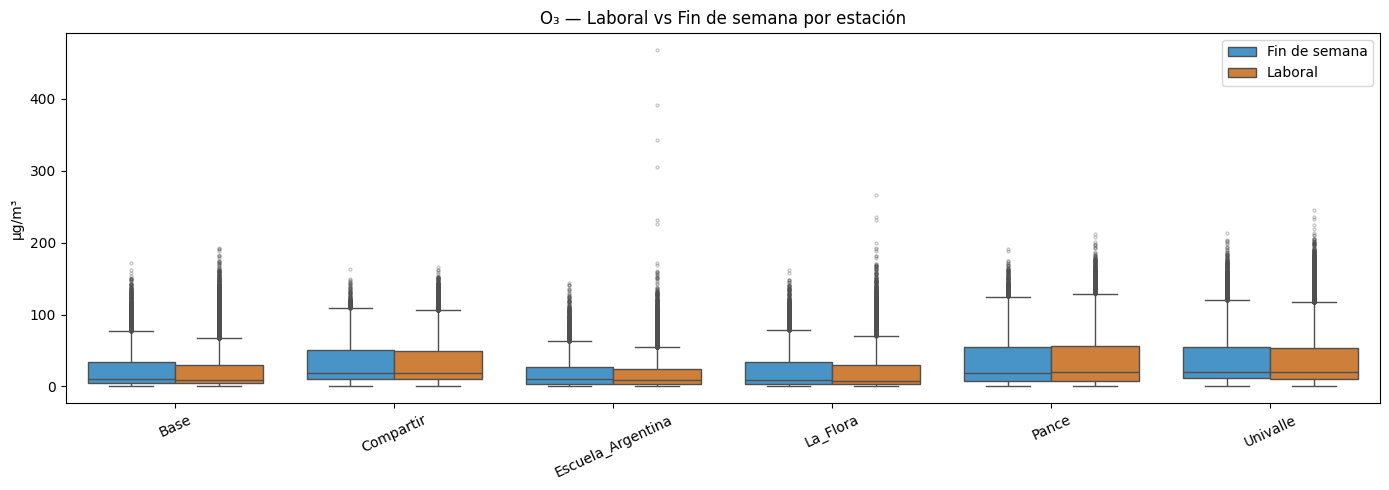

In [38]:
# ══════════════════════════════════════════════════════════════════
# BLOQUE 4 — DIFERENCIA LABORAL vs FIN DE SEMANA
# ══════════════════════════════════════════════════════════════════

df['tipo_dia'] = df['dia_semana'].apply(
    lambda x: 'Fin de semana' if x >= 5 else 'Laboral'
)

print("TEST ESTADÍSTICO: ¿Difieren los niveles entre días laborales y fin de semana?")
print("(Mann-Whitney U — no paramétrico, robusto a no normalidad)\n")

for col, (nombre, _) in contaminantes.items():
    estaciones = sorted(df[df[col].notna()]['estacion'].unique())
    if not estaciones:
        continue

    print(f"\n{'─'*60}")
    print(f"  {nombre}")
    print(f"{'─'*60}")

    for est in estaciones:
        lab = df[(df['estacion']==est) &
                 (df['tipo_dia']=='Laboral') &
                  df[col].notna()][col]
        fds = df[(df['estacion']==est) &
                 (df['tipo_dia']=='Fin de semana') &
                  df[col].notna()][col]
        if len(lab) < 10 or len(fds) < 10:
            continue

        stat, p = mannwhitneyu(lab, fds, alternative='two-sided')
        diff_pct = (lab.mean() - fds.mean()) / fds.mean() * 100
        sig = '✓ SÍ difieren' if p < 0.05 else '✗ NO difieren'
        print(f"  {est:22s} | Lab: {lab.mean():.2f}  FdS: {fds.mean():.2f}  "
              f"Δ={diff_pct:+.1f}%  p={p:.4f}  → {sig}")

    # Boxplot laboral vs fin de semana por estación
    datos = df[df[col].notna()]
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.boxplot(data=datos, x='estacion', y=col,
                hue='tipo_dia', palette=['#3498db','#e67e22'],
                flierprops={'marker':'o','markersize':2,'alpha':0.3},
                ax=ax)
    ax.set_title(f'{nombre} — Laboral vs Fin de semana por estación')
    ax.set_xlabel('')
    ax.set_ylabel('µg/m³')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='')
    plt.tight_layout()
    plt.savefig(f'figuras/laboral_fds_{col}.png', bbox_inches='tight', dpi=150)
    plt.show()

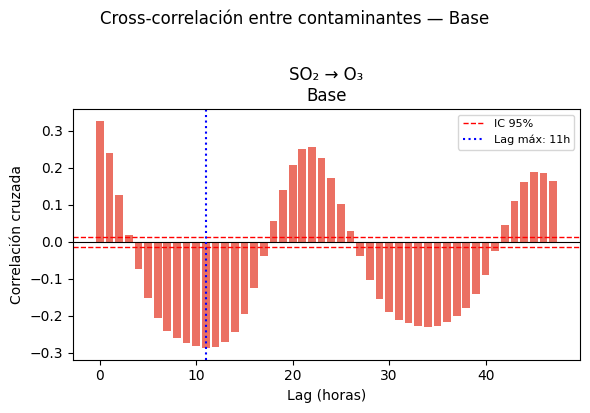

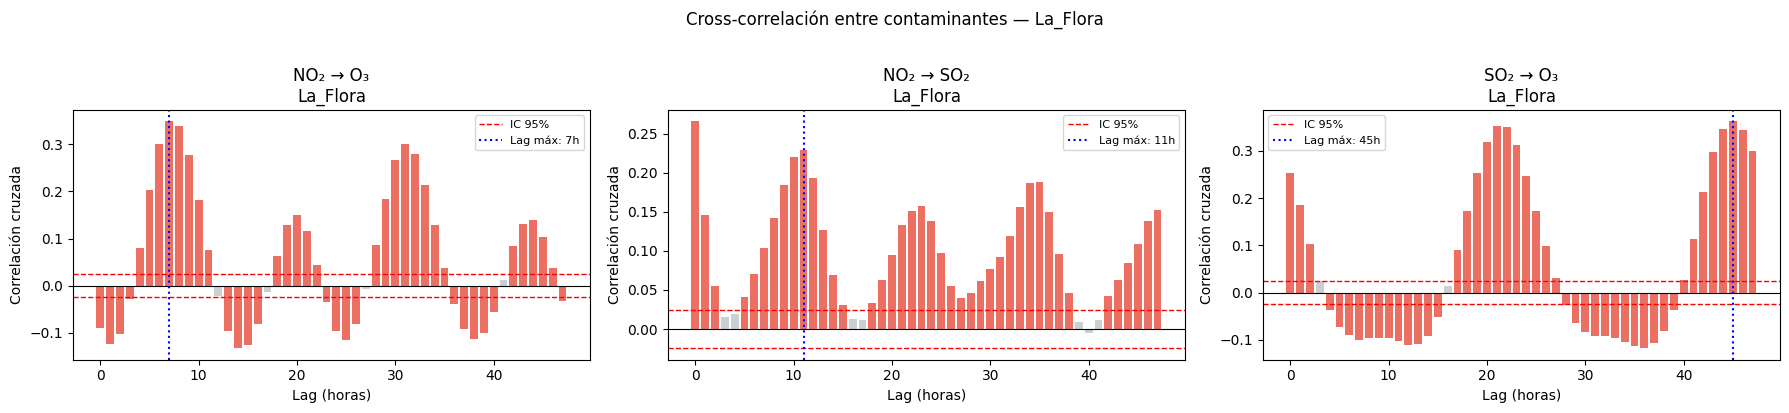

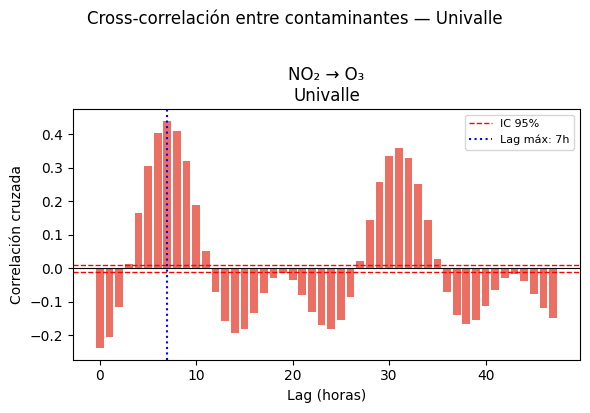

In [39]:
# ══════════════════════════════════════════════════════════════════
# BLOQUE 7 — CORRELACIÓN CRUZADA ENTRE CONTAMINANTES
# ¿NO₂ anticipa O₃? ¿SO₂ y NO₂ comparten fuente?
# ══════════════════════════════════════════════════════════════════

from statsmodels.tsa.stattools import ccf

# Estaciones que miden al menos 2 contaminantes
pares_analizar = [
    ('no2_ug_m3', 'o3_ug_m3',  'NO₂ → O₃'),
    ('no2_ug_m3', 'so2_ug_m3', 'NO₂ → SO₂'),
    ('so2_ug_m3', 'o3_ug_m3',  'SO₂ → O₃'),
]

for est in sorted(df['estacion'].unique()):
    cols_est = [c for c in ['no2_ug_m3','so2_ug_m3','o3_ug_m3']
                if df[(df['estacion']==est) & df[c].notna()][c].count() > 100]

    if len(cols_est) < 2:
        continue

    sub = (df[df['estacion']==est]
           .set_index('fecha_hora')[cols_est]
           .resample('H').mean()
           .dropna())

    if len(sub) < 200:
        continue

    pares_disp = [(a, b, lbl) for a, b, lbl in pares_analizar
                  if a in cols_est and b in cols_est]

    if not pares_disp:
        continue

    fig, axes = plt.subplots(1, len(pares_disp),
                             figsize=(6*len(pares_disp), 4))
    if len(pares_disp) == 1:
        axes = [axes]

    for i, (col_a, col_b, lbl) in enumerate(pares_disp):
        cc = ccf(sub[col_a].values, sub[col_b].values, nlags=48)
        ic = 1.96 / np.sqrt(len(sub))

        axes[i].bar(range(len(cc)), cc,
                    color=['#e74c3c' if abs(v) > ic else '#bdc3c7' for v in cc],
                    alpha=0.8)
        axes[i].axhline( ic, color='red', linestyle='--', lw=1, label='IC 95%')
        axes[i].axhline(-ic, color='red', linestyle='--', lw=1)
        axes[i].axhline(0,   color='black', lw=0.8)

        lag_max = np.argmax(np.abs(cc[1:]))+1
        axes[i].axvline(lag_max, color='blue', linestyle=':', lw=1.5,
                        label=f'Lag máx: {lag_max}h')
        axes[i].set_title(f'{lbl}\n{est}')
        axes[i].set_xlabel('Lag (horas)')
        axes[i].set_ylabel('Correlación cruzada')
        axes[i].legend(fontsize=8)

    plt.suptitle(f'Cross-correlación entre contaminantes — {est}',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(f'figuras/ccf_{est}.png', bbox_inches='tight', dpi=150)
    plt.show()